In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Data.txt")

# Data Understanding

In [3]:
data.head(10)

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0
5,"ford,galaxie,500",8,429.0,198.0,4341,10.0,70,1,15.0
6,"chevrolet,impala",8,454.0,220.0,4354,9.0,70,1,14.0
7,"plymouth,fury,iii",8,440.0,215.0,4312,8.5,70,1,14.0
8,"pontiac,catalina",8,455.0,225.0,4425,10.0,70,1,14.0
9,"amc,ambassador,dpl",8,390.0,190.0,3850,8.5,70,1,15.0


## Dataset shape and data types

In [4]:
data.shape

(398, 9)

#### the dataset has 398 rows and 9 columns - 1 target, 7 features and  1 identifier

In [5]:
data.dtypes

car_name            str
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object

## Descriptive statistics and missing values

In [6]:
data.describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


### Detecting missing values and Duplicates

#### I'm aware that this part only appears on Part B on the provided PDF, but to me it is very reasonable to do missing values and duplicates tretament before any orrelation and statistical analysis, otherwise I'd be working with possible "garbage" data.

In [7]:
data.isnull().any()

car_name        False
cylinders       False
displacement    False
horsepower       True
weight          False
acceleration    False
model_year      False
origin          False
mpg             False
dtype: bool

In [8]:
data.isnull().sum()

car_name        0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

#### Variable horsepower has 6 missing values

In [9]:
missing_mask = data.isnull()
missing_rows = data[missing_mask['horsepower']]
missing_rows

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
32,"ford,pinto",4,98.0,NaN,2046,19.0,71,1,25.0
126,"ford,maverick",6,200.0,NaN,2875,17.0,74,1,21.0
330,"renault,lecar,deluxe",4,85.0,NaN,1835,17.3,80,2,40.9
336,"ford,mustang,cobra",4,140.0,NaN,2905,14.3,80,1,23.6
354,"renault,18i",4,100.0,NaN,2320,15.8,81,2,34.5
374,"amc,concord,dl",4,151.0,NaN,3035,20.5,82,1,23.0


In [10]:
missing_rows.describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
count,6.000000,6.00000,0.0,6.000000,6.000000,6.000000,6.000000,6.000000
mean,4.333333,129.00000,NaN,2502.666667,17.316667,78.000000,1.333333,28.000000
std,0.816497,43.32205,NaN,504.296209,2.212163,4.427189,0.516398,7.886951
min,4.000000,85.00000,NaN,1835.000000,14.300000,71.000000,1.000000,21.000000
25%,4.000000,98.50000,NaN,2114.500000,16.100000,75.500000,1.000000,23.150000
50%,4.000000,120.00000,NaN,2597.500000,17.150000,80.000000,1.000000,24.300000
75%,4.000000,148.25000,NaN,2897.500000,18.575000,80.750000,1.750000,32.125000
max,6.000000,200.00000,NaN,3035.000000,20.500000,82.000000,2.000000,40.900000


In [11]:
data.describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


Since we have only 6 missing values (1.5 % of our data), and by looking at the description summary of the data, I don't check any association that allows us to correlate any feature with the fact the data is missing. I also don't consider that this is a MNAR situation. Since this is a such a low %, it doesn't make sense to do a deep statistical analysis to understand any pattern in the missing data to better understand how to deal with it. I'm just gonna drop these 6 observations. 

In [12]:
data.dropna(axis="index", inplace=True)
data

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,"ford,mustang,gl",4,140.0,86.0,2790,15.6,82,1,27.0
394,"vw,pickup",4,97.0,52.0,2130,24.6,82,2,44.0
395,"dodge,rampage",4,135.0,84.0,2295,11.6,82,1,32.0
396,"ford,ranger",4,120.0,79.0,2625,18.6,82,1,28.0


#### Checking if there are no missing values

In [13]:
data.isnull().sum()

car_name        0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

#### Checking for duplicates just in case there are duplicated lines

In [14]:
data.duplicated().any()

np.False_

## Variables' Distributions and Outliers

### 'car_name' variable treatment
The "car_name" identifier could possibly be a predictor for our target if we consider only the brand. So for now I'm just gonna transform the column into a new one, containing only the car brands

In [15]:
data['car_name'] = data['car_name'].str.split(',').str[0]

In [16]:
data

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,chevrolet,8,307.0,130.0,3504,12.0,70,1,18.0
1,buick,8,350.0,165.0,3693,11.5,70,1,15.0
2,plymouth,8,318.0,150.0,3436,11.0,70,1,18.0
3,amc,8,304.0,150.0,3433,12.0,70,1,16.0
4,ford,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,ford,4,140.0,86.0,2790,15.6,82,1,27.0
394,vw,4,97.0,52.0,2130,24.6,82,2,44.0
395,dodge,4,135.0,84.0,2295,11.6,82,1,32.0
396,ford,4,120.0,79.0,2625,18.6,82,1,28.0


After transforming the values into a new column I want to make sure that the there aren't any spell errors or inconsistencies in the data, which appears to have (chevroelt, vw and volkswagen are the same, vokswagen, mercedes and mercedes-benz, maxda, toyouta)

In [17]:
data['car_name'].unique()

array(['chevrolet', 'buick', 'plymouth', 'amc', 'ford', 'pontiac',
       'dodge', 'toyota', 'datsun', 'volkswagen', 'peugeot', 'audi',
       'saab', 'bmw', 'chevy', 'hi', 'mercury', 'opel', 'fiat',
       'oldsmobile', 'chrysler', 'mazda', 'volvo', 'renault', 'toyouta',
       'maxda', 'honda', 'subaru', 'chevroelt', 'capri', 'vw',
       'mercedes-benz', 'cadillac', 'mercedes', 'vokswagen', 'triumph',
       'nissan'], dtype=object)

In [18]:
data['car_name'] = data['car_name'].replace({
    'chevroelt': 'chevrolet',
    'chevy': 'chevrolet',
    'maxda': 'mazda',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'mercedes': 'mercedes-benz'
    })

In [19]:
data

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,chevrolet,8,307.0,130.0,3504,12.0,70,1,18.0
1,buick,8,350.0,165.0,3693,11.5,70,1,15.0
2,plymouth,8,318.0,150.0,3436,11.0,70,1,18.0
3,amc,8,304.0,150.0,3433,12.0,70,1,16.0
4,ford,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,ford,4,140.0,86.0,2790,15.6,82,1,27.0
394,volkswagen,4,97.0,52.0,2130,24.6,82,2,44.0
395,dodge,4,135.0,84.0,2295,11.6,82,1,32.0
396,ford,4,120.0,79.0,2625,18.6,82,1,28.0


In [20]:
data['car_name'].unique()

array(['chevrolet', 'buick', 'plymouth', 'amc', 'ford', 'pontiac',
       'dodge', 'toyota', 'datsun', 'volkswagen', 'peugeot', 'audi',
       'saab', 'bmw', 'hi', 'mercury', 'opel', 'fiat', 'oldsmobile',
       'chrysler', 'mazda', 'volvo', 'renault', 'honda', 'subaru',
       'capri', 'mercedes-benz', 'cadillac', 'triumph', 'nissan'],
      dtype=object)

In [21]:
data.to_csv('Projeto_mpg')

### Variables Distributions

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
counts = data['car_name'].value_counts()
print(f"These are the car names' list: \n{counts}")

These are the car names' list: 
car_name
ford             48
chevrolet        47
plymouth         31
dodge            28
amc              27
toyota           26
datsun           23
volkswagen       22
buick            17
pontiac          16
honda            13
mazda            12
mercury          11
oldsmobile       10
peugeot           8
fiat              8
audi              7
chrysler          6
volvo             6
saab              4
opel              4
subaru            4
renault           3
mercedes-benz     3
bmw               2
cadillac          2
hi                1
capri             1
triumph           1
nissan            1
Name: count, dtype: int64


In [24]:
print(f"There are {counts.count()} unique car names, I'm gonna choose the top 20 (66%) car names to show the frequency")

There are 30 unique car names, I'm gonna choose the top 20 (66%) car names to show the frequency


In [25]:
top_n = 20
top_counts = counts.head(top_n) #select first 20 elemtns
other_counts= counts.iloc[top_n :] #note to myself: remember, the starting index is zero, I'm starrting at index 20, element 21

print(f'{top_counts} \n\n {other_counts}')

car_name
ford          48
chevrolet     47
plymouth      31
dodge         28
amc           27
toyota        26
datsun        23
volkswagen    22
buick         17
pontiac       16
honda         13
mazda         12
mercury       11
oldsmobile    10
peugeot        8
fiat           8
audi           7
chrysler       6
volvo          6
saab           4
Name: count, dtype: int64 

 car_name
opel             4
subaru           4
renault          3
mercedes-benz    3
bmw              2
cadillac         2
hi               1
capri            1
triumph          1
nissan           1
Name: count, dtype: int64


In [26]:
# let's sum the 'other' categories and add it to the series
other_total = other_counts.sum()
print(other_total)
top_counts ['Other'] = other_total
top_counts.sort_values(ascending=False, inplace=True)
print(top_counts)

22
car_name
ford          48
chevrolet     47
plymouth      31
dodge         28
amc           27
toyota        26
datsun        23
volkswagen    22
Other         22
buick         17
pontiac       16
honda         13
mazda         12
mercury       11
oldsmobile    10
fiat           8
peugeot        8
audi           7
chrysler       6
volvo          6
saab           4
Name: count, dtype: int64


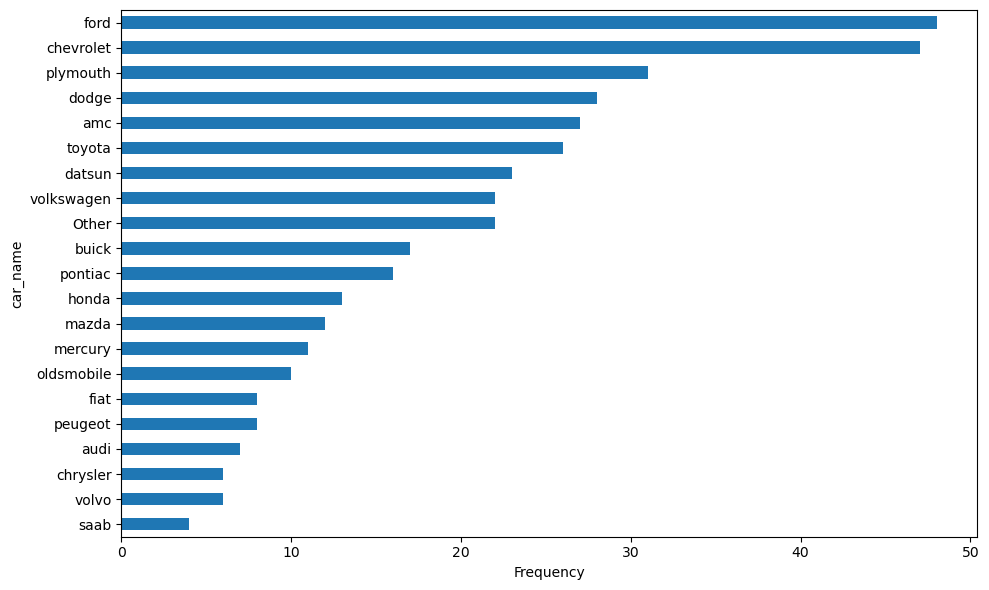

In [27]:
plt.figure(figsize=(10, 6))
top_counts.plot(kind='barh')
plt.xlabel('Frequency')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [28]:
data.dtypes

car_name         object
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object

In [29]:
# changing the new column data type from 'object' to 'str' -> it will be important later when plotting the variables
data['car_name'] = pd.Series(data['car_name'], dtype=pd.StringDtype())

In [30]:
# even thoug here the 'weight' variable appears to have only integers, it can be a continuous one, I'll convert it 
data['weight'] = pd.Series(data['weight'], dtype = 'float64')

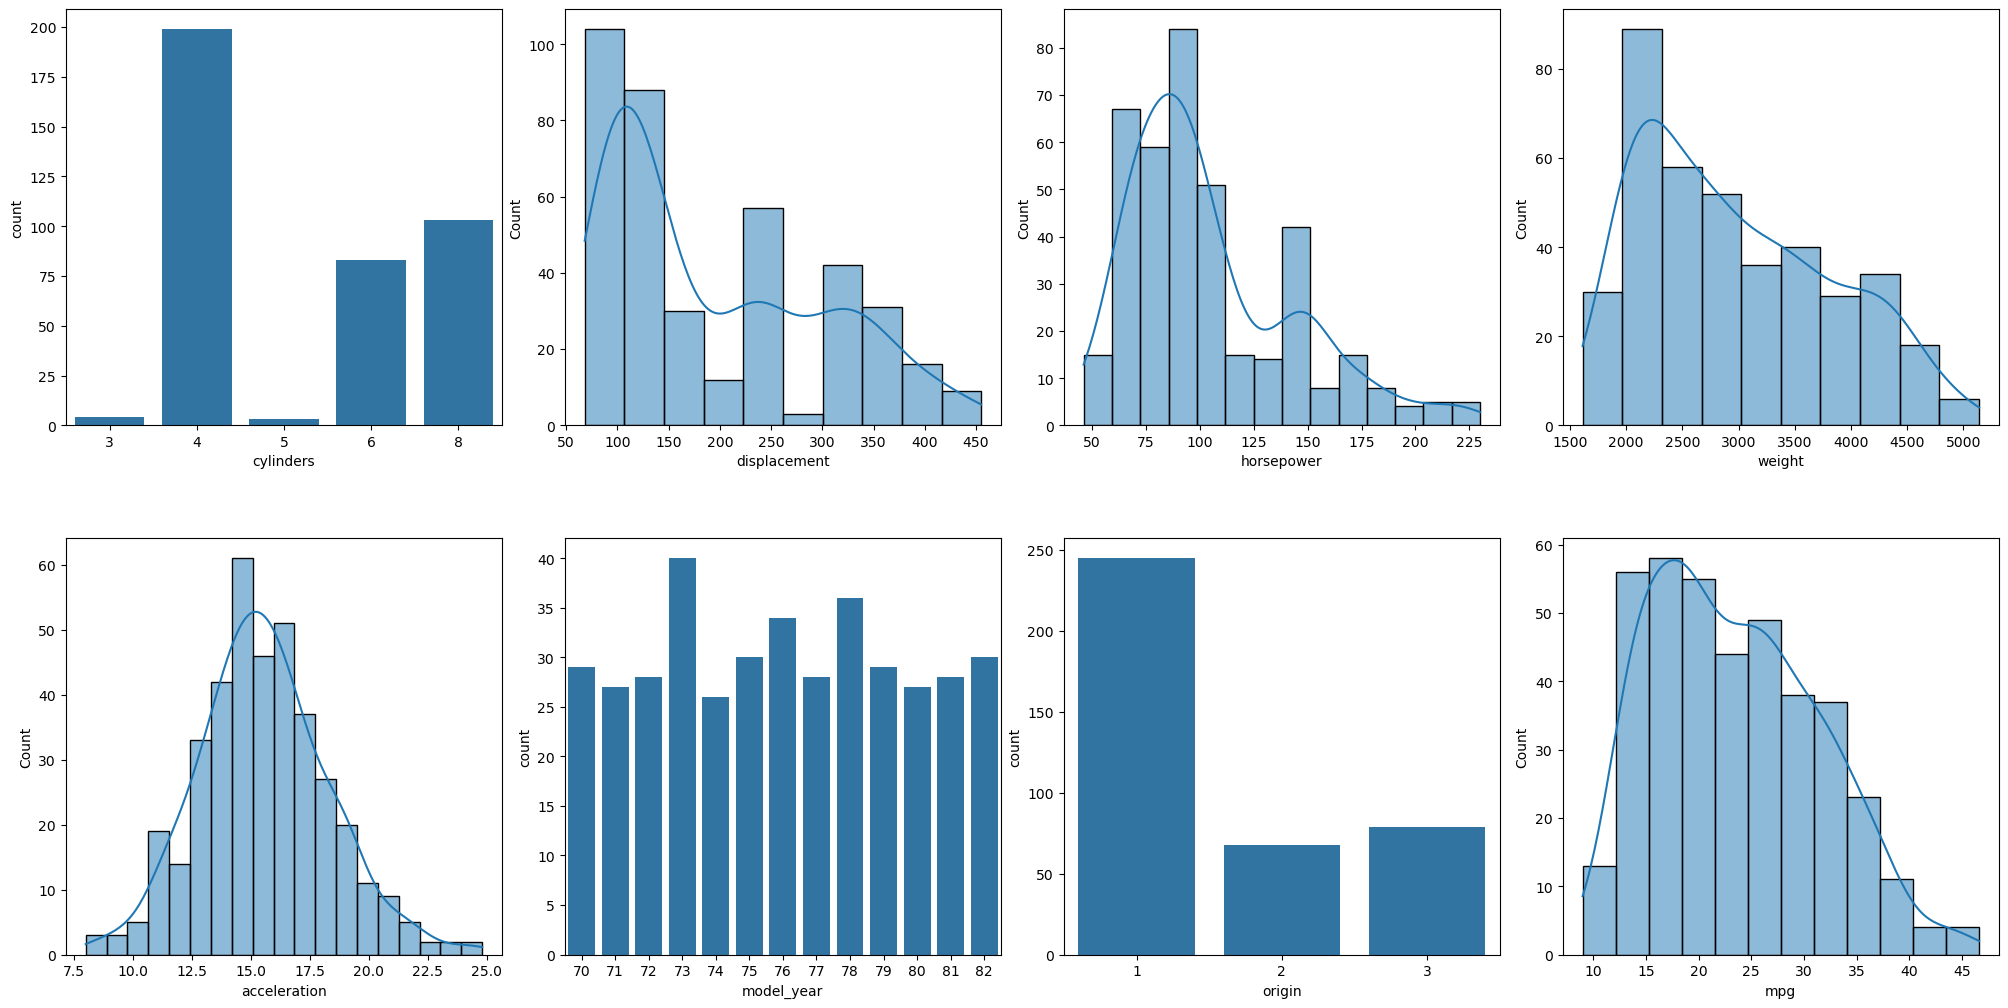

In [31]:
# ploting the distributions using consistent plot with the data type
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
num = 0
axs = axs.flatten()

for variable, col_data in data.items():
    if col_data.dtype == 'float64':
        sns.histplot(data=col_data, kde=True, ax=axs[num])
    elif col_data.dtype == 'int64':
        sns.countplot(data=data, x=variable,  ax=axs[num])
    else:
        continue
    num += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


Let's plot the cylinders variable againts displacement, horsepower and weight in box plots

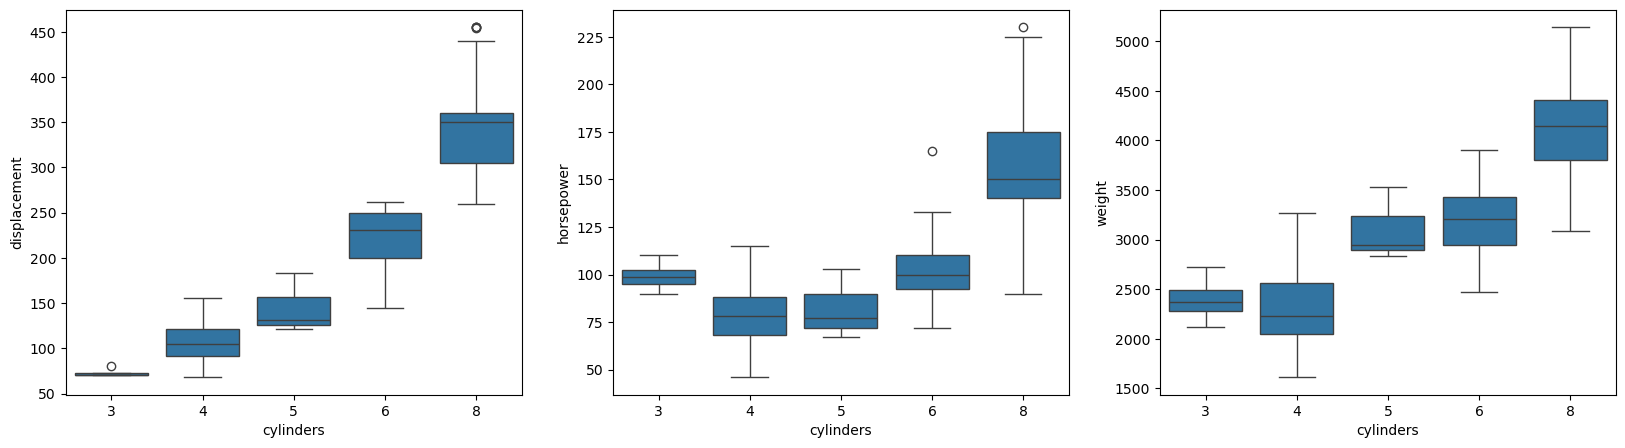

In [32]:
y_axs = ['displacement', 'horsepower', 'weight']

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(20, 5))
num = 0
axs = axs.flatten()
for variable in y_axs:
    sns.boxplot(x=data['cylinders'], y=data[variable], ax=axs[num])
    num += 1


Plotting the target 

<Axes: ylabel='mpg'>

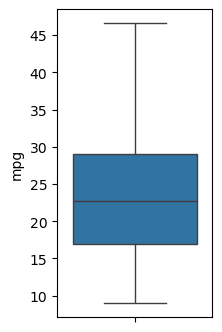

In [33]:
fig, ax = plt.subplots(figsize=(2, 4))
sns.boxplot(data=data['mpg'])

Let's check the skewness for each variable (I don't include car_names)

In [34]:
data.iloc[:, 1:].skew()

cylinders       0.508109
displacement    0.701669
horsepower      1.087326
weight          0.519586
acceleration    0.291587
model_year      0.019688
origin          0.915185
mpg             0.457092
dtype: float64

#### Doing an analysis to each variable:
- cylinders: almost 50% of the points are concentrated on the number 4 (which is more common), but there's still 25% of cars with 8 cylinders and 20% 6 cylinders. Usually more cylinders means a more powerful engine, so we have a big slice of average cars, but nevertheless there's a clear presence of more powerfull cars. 
  
- displacement, horsepower, weight: all right skewed distributions, which is something expected since more cars tend to have 4 cylinders (and a less hp, cc and weight), but there are a few with more engine power/capacity or weight - as we can confim with the cylinders variable distribution (more cylinders -> more hp and cc). Notice that the first two features here have a less smooth distribution compared with the last one, which means that the values are dispersed in a more uniform way in the weight variable, as the others two have a big concentration about a range, and then little concentrations around other smaller ranges.
- displacement: most cars' engines have between 70-150 cubic centimeters, then there are a few around 225cc and a little less around 340cc (more powerfull engines) - we can see that also in the boxplot chart where the Q3 of 6 and 8 cylinders has a more concentration than Q1 
- horsepower: biggest concentration around the range 65-110 hp, and a second way lesser concentration around 140 hp - also spotted in the 8 cylinder boxplot Q1
- horsepower and displacement have a quite similar distribution: both have a big peak at the initial ranges, and then a second and thir little peaks - they follow the pattern of the cylinders variable - as the number of cylinders increases, these 3 variables tend to increase as well, we'll check later but there's a high likelihood of them being very linear correlated
- I also notice something interesting: look that horsepower has a concentration in Q1 at 5 cylinders besides the one at 8, but notice that in the histogram, we only have a second little peak besides the main one, but these is proably because the 3 and 5 cylinder's cars have a very low representation on the data. The same goes for the weight, where we have 3 and 4 cylinders in the same weight, as with 5 and 6. 
  
- acceleration: this variable as a norma distribution with the data quite well dispersed around the mean in a tipicall bell shape form. Take into consideration that if I want to normalize features, I'll remove this feature from that normalization 

- model_year: year 73, 78 and 76 have a larger fequency, even though the other years are quite similar between each other, in the big picture, is a even distribution among the different years. 

- origin: there's a clear discrepancy between 1(USA) and the others (2 - Europe; 3 - Japan), which can be confirmed when we look at the car_names variable with a high dominance from american's manufacturers 
- car_name: almost 25% of the car names belong to ford and chevrolet categories, and around the first 40% of the brands are USA based. 

- mpg: our target has a smooth right skewed distribution - like weight -, with a peak at 18 mpg, and then it starts to fall. Most of the cars belong to the 18-29 mpg range, which means there are only in the Q4 more fuel efficient cars. In other words, most cars are not that efficient.  



### Outliers

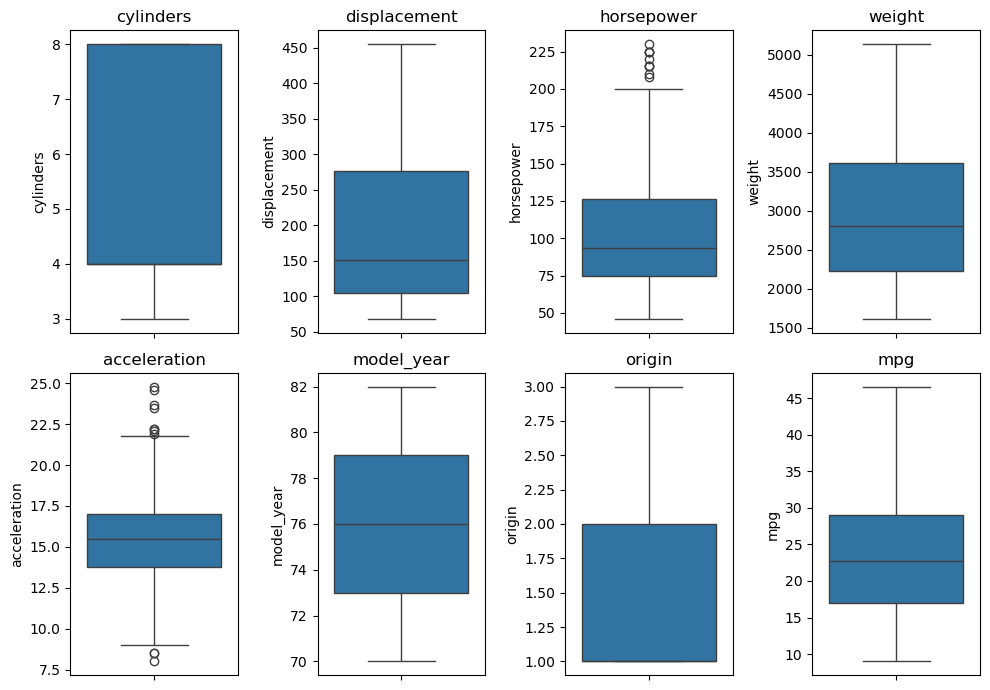

In [35]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(10, 7))
num = 0
axs = axs.flatten()

for variable, col_data in data.iloc[:, 1:].items(): 
    sns.boxplot(data=col_data, ax=axs[num])
    axs[num].set_title(variable)
    num += 1

plt.tight_layout()

##### Let's investigate a little about this outliers

In [36]:
outlier_rows = []

for variable, col_data in data.iloc[:, 1:].items():
    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1
    upper_lim = q3 + 1.5*iqr
    lower_lim = q1 - 1.5* iqr
    total_out = col_data[(col_data > upper_lim) | (col_data < lower_lim)] 
    perc = (total_out.size / data[variable].size) *100

    if total_out.size > 0:
        print(f'\n{variable} number of outliers = {total_out.size}')
        print(f'{variable} percentage of outliers = {round(perc)}%')

        df_out = data.loc[total_out.index]
        df_out['outlier_variable'] = variable
        df_out['outlier_value'] = total_out
        df_out['upper_lim'] = upper_lim
        df_out['lower_lim'] = lower_lim
        outlier_rows.append(df_out)
        
    else: 
        print(f'\n{variable} as no outliers')  
        
df_out = pd.concat(outlier_rows)
df_out.sort_values(by= ['outlier_variable', 'outlier_value'], ascending= False, inplace=True)
df_out


cylinders as no outliers

displacement as no outliers

horsepower number of outliers = 10
horsepower percentage of outliers = 3%

weight as no outliers

acceleration number of outliers = 11
acceleration percentage of outliers = 3%

model_year as no outliers

origin as no outliers

mpg as no outliers


,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg,outlier_variable,outlier_value,upper_lim,lower_lim
116,pontiac,8,400.0,230.0,4278.0,9.5,73,1,16.0,horsepower,230.0,202.5,-1.5
8,pontiac,8,455.0,225.0,4425.0,10.0,70,1,14.0,horsepower,225.0,202.5,-1.5
13,buick,8,455.0,225.0,3086.0,10.0,70,1,14.0,horsepower,225.0,202.5,-1.5
95,buick,8,455.0,225.0,4951.0,11.0,73,1,12.0,horsepower,225.0,202.5,-1.5
6,chevrolet,8,454.0,220.0,4354.0,9.0,70,1,14.0,horsepower,220.0,202.5,-1.5
7,plymouth,8,440.0,215.0,4312.0,8.5,70,1,14.0,horsepower,215.0,202.5,-1.5
25,ford,8,360.0,215.0,4615.0,14.0,70,1,10.0,horsepower,215.0,202.5,-1.5
94,chrysler,8,440.0,215.0,4735.0,11.0,73,1,13.0,horsepower,215.0,202.5,-1.5
27,dodge,8,318.0,210.0,4382.0,13.5,70,1,11.0,horsepower,210.0,202.5,-1.5
67,mercury,8,429.0,208.0,4633.0,11.0,72,1,11.0,horsepower,208.0,202.5,-1.5


As we check, most outliers do look not so abnormal values, or even errors. The horsepower ones represent cars with more power, and it looks something very reasonable values, as with the acceleration ones, except, and this is the important pat, the outliers below the lower limit. If you look closer you can see that the 3 cars have 8 cylindersd and 160+ horsepower, so that to me, is a true outlier, which I'll remove. The others I'll keep. 

Also, I'm gonna try some transformations to adjust the data distributions of horsepower and displacement variables, rechek outliers and see if it improves the correlation with out target. 

In [37]:
index_drop = [7, 9, 11]
rows_drop = data.loc[index_drop]
rows_drop

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
7,plymouth,8,440.0,215.0,4312.0,8.5,70,1,14.0
9,amc,8,390.0,190.0,3850.0,8.5,70,1,15.0
11,plymouth,8,340.0,160.0,3609.0,8.0,70,1,14.0


In [38]:
print(f"Original size: {len(data)}")
data.drop(index= rows_drop.index, inplace=True)
print(f"\nAfter dropping: {len(data)}")

Original size: 392

After dropping: 389


#### Feature Transformation

I'll apply a log transformation on displacement and horsepower features since they're right skewed

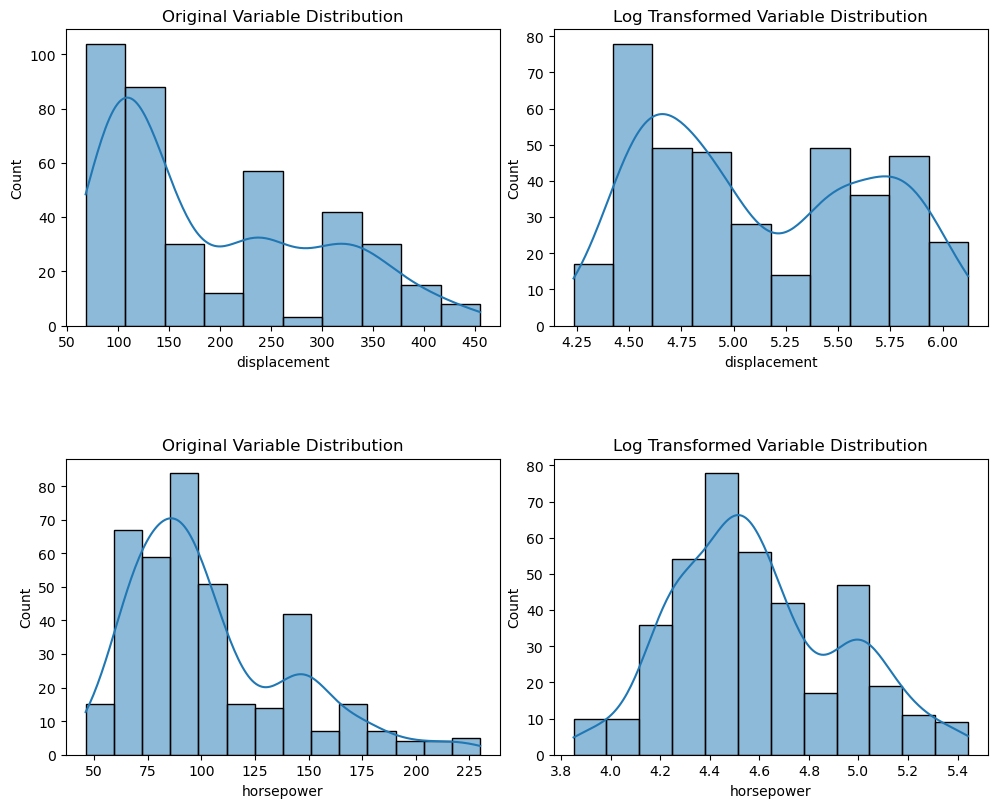

In [39]:
variables_transf = ['displacement', 'horsepower']
data_transf = pd.DataFrame()

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 8))
num = 0
axs = axs.flatten()

for variable in variables_transf:
    sns.histplot(data=data[variable], kde=True, ax=axs[num])
    axs[num].set_title("Original Variable Distribution")
    num += 1

    data_transf[variable] = np.log1p(data[variable])
    sns.histplot(data= data_transf[variable], kde=True, ax=axs[num])
    axs[num].set_title("Log Transformed Variable Distribution")
    num += 1
   
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

Let's check outliers behaviour after the feature transformation 

In [40]:
for variable, col_data in data_transf.items():
    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1
    upper_lim = q3 + 1.5*iqr
    lower_lim = q1 - 1.5* iqr
    total_out = col_data[(col_data > upper_lim) | (col_data < lower_lim)] 
    perc = (total_out.size / data_transf[variable].size) *100

    if total_out.size > 0:
        print(f'\n{variable} number of outliers = {total_out.size}')
        print(f'{variable} percentage of outliers = {round(perc)}%')
        
    else: 
        print(f'\n{variable} as no outliers')


displacement as no outliers

horsepower as no outliers


The transformations helped reducing the outliers. I'll create a second dataset, so I can compare both the original and the transformed features with the target and see if this helped improve the relationship.  

In [41]:
# current second dataset
data_transf

,displacement,horsepower
0,5.730100,4.875197
1,5.860786,5.111988
2,5.765191,5.017280
3,5.720312,5.017280
4,5.713733,4.948760
...,...,...
393,4.948760,4.465908
394,4.584967,3.970292
395,4.912655,4.442651
396,4.795791,4.382027


In [42]:
for variable in data.columns:
    if variable not in data_transf.columns:
        data_transf[variable] = data[variable]
    else:
        continue 
    
# sorting it accordingly with my first dataframe    
data_transf = data_transf.reindex(columns=data.columns)
data_transf

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,chevrolet,8,5.730100,4.875197,3504.0,12.0,70,1,18.0
1,buick,8,5.860786,5.111988,3693.0,11.5,70,1,15.0
2,plymouth,8,5.765191,5.017280,3436.0,11.0,70,1,18.0
3,amc,8,5.720312,5.017280,3433.0,12.0,70,1,16.0
4,ford,8,5.713733,4.948760,3449.0,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,ford,4,4.948760,4.465908,2790.0,15.6,82,1,27.0
394,volkswagen,4,4.584967,3.970292,2130.0,24.6,82,2,44.0
395,dodge,4,4.912655,4.442651,2295.0,11.6,82,1,32.0
396,ford,4,4.795791,4.382027,2625.0,18.6,82,1,28.0


## Features and Target Relationships

### Continuous Variables Correlations

We have different measures to calculate the correlation between variables based on it's data type. Let's first start by building a scatterplot matrix for the continuous variables 

In [43]:
data.dtypes

car_name         string
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object

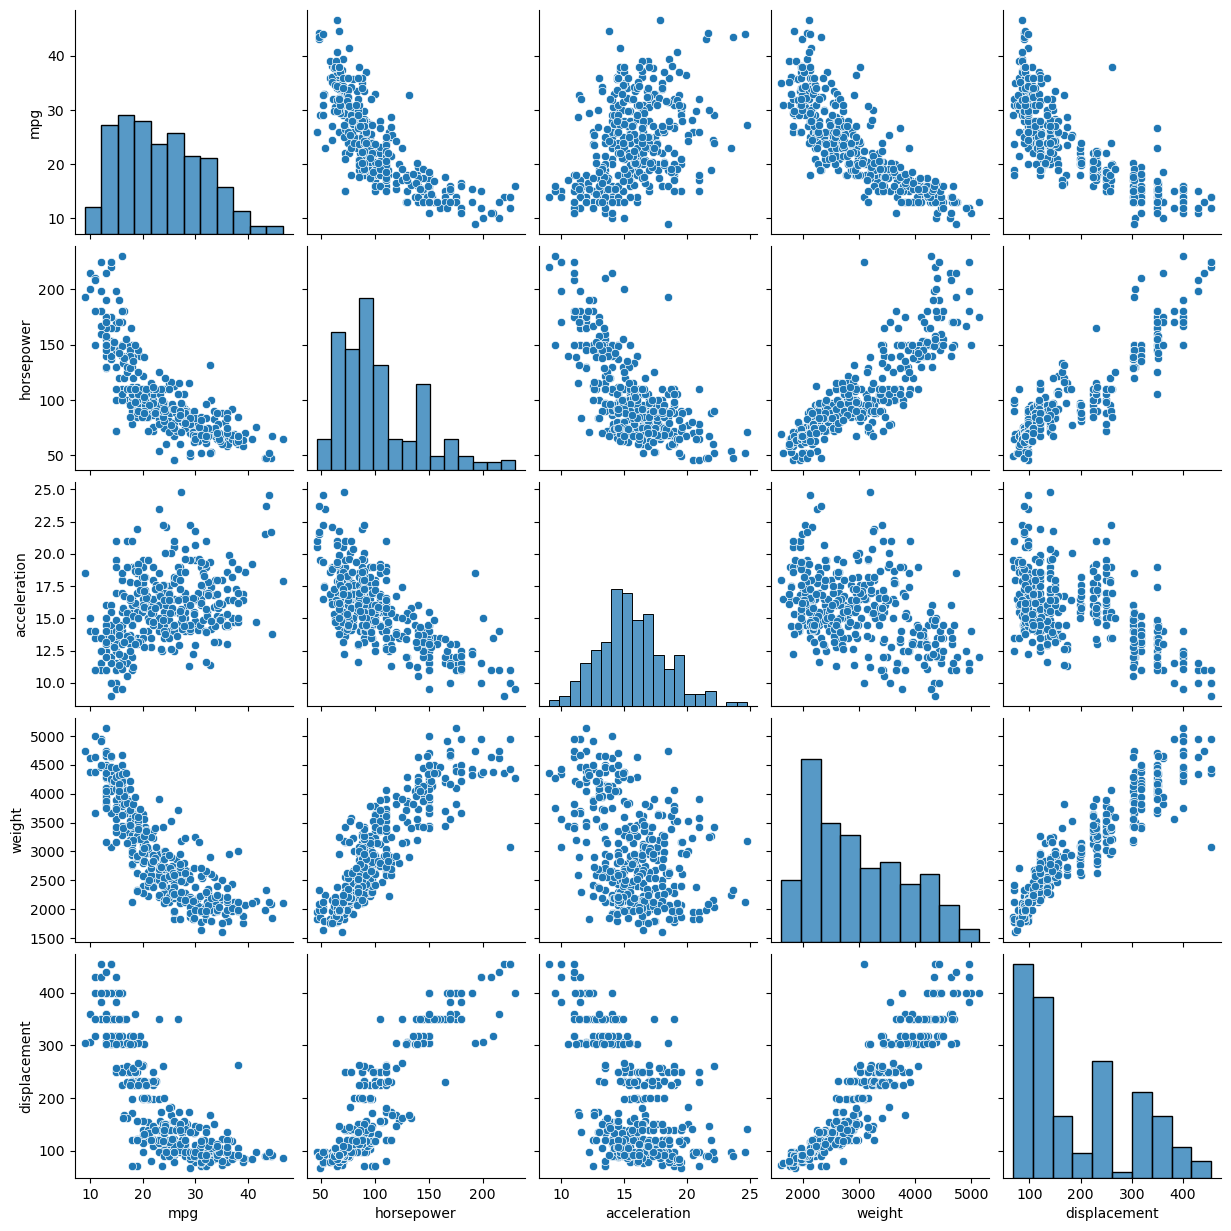

In [44]:
sns.pairplot(data=data, vars={'displacement','horsepower', 'weight', 'acceleration', 'mpg'})

##### Analysis:
Look how the displacement, horsepower and weight variables present a good negative association with the target. Accelerarion on the other hand also has a linear relationship, in this case positive, but it looks less strong tha the previous 2. 
But we can also check that probably these 3 features are also correlated with each other, as we already saw previously that they follow a similar distribution. We'll check later a more precise value, but if that's the case, we'll need to take care of it. 

For now let's just look how the original vs transformed features perform against the target

#### Original vs Transformed Data

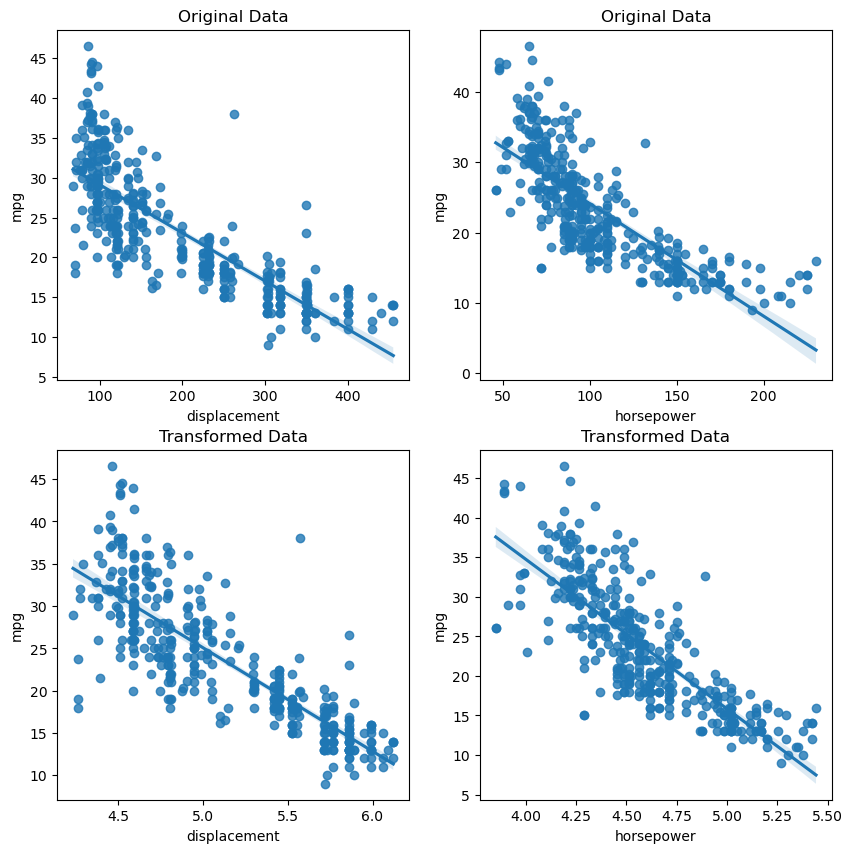

In [45]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
num = 0
axs = axs.flatten()

var = ['displacement', 'horsepower']

for feature in var:
    sns.regplot(data=data, x=feature, y='mpg', ax=axs[num])
    axs[num].set_title("Original Data")
    num += 1

for feature in var:
    sns.regplot(data=data_transf, x=feature, y='mpg', ax=axs[num])
    axs[num].set_title("Transformed Data")
    num += 1


Checking the charts I believe (we'll confirm later) that the original data has a better relationship with the target

### Discrete and Categorical Variables Correlations

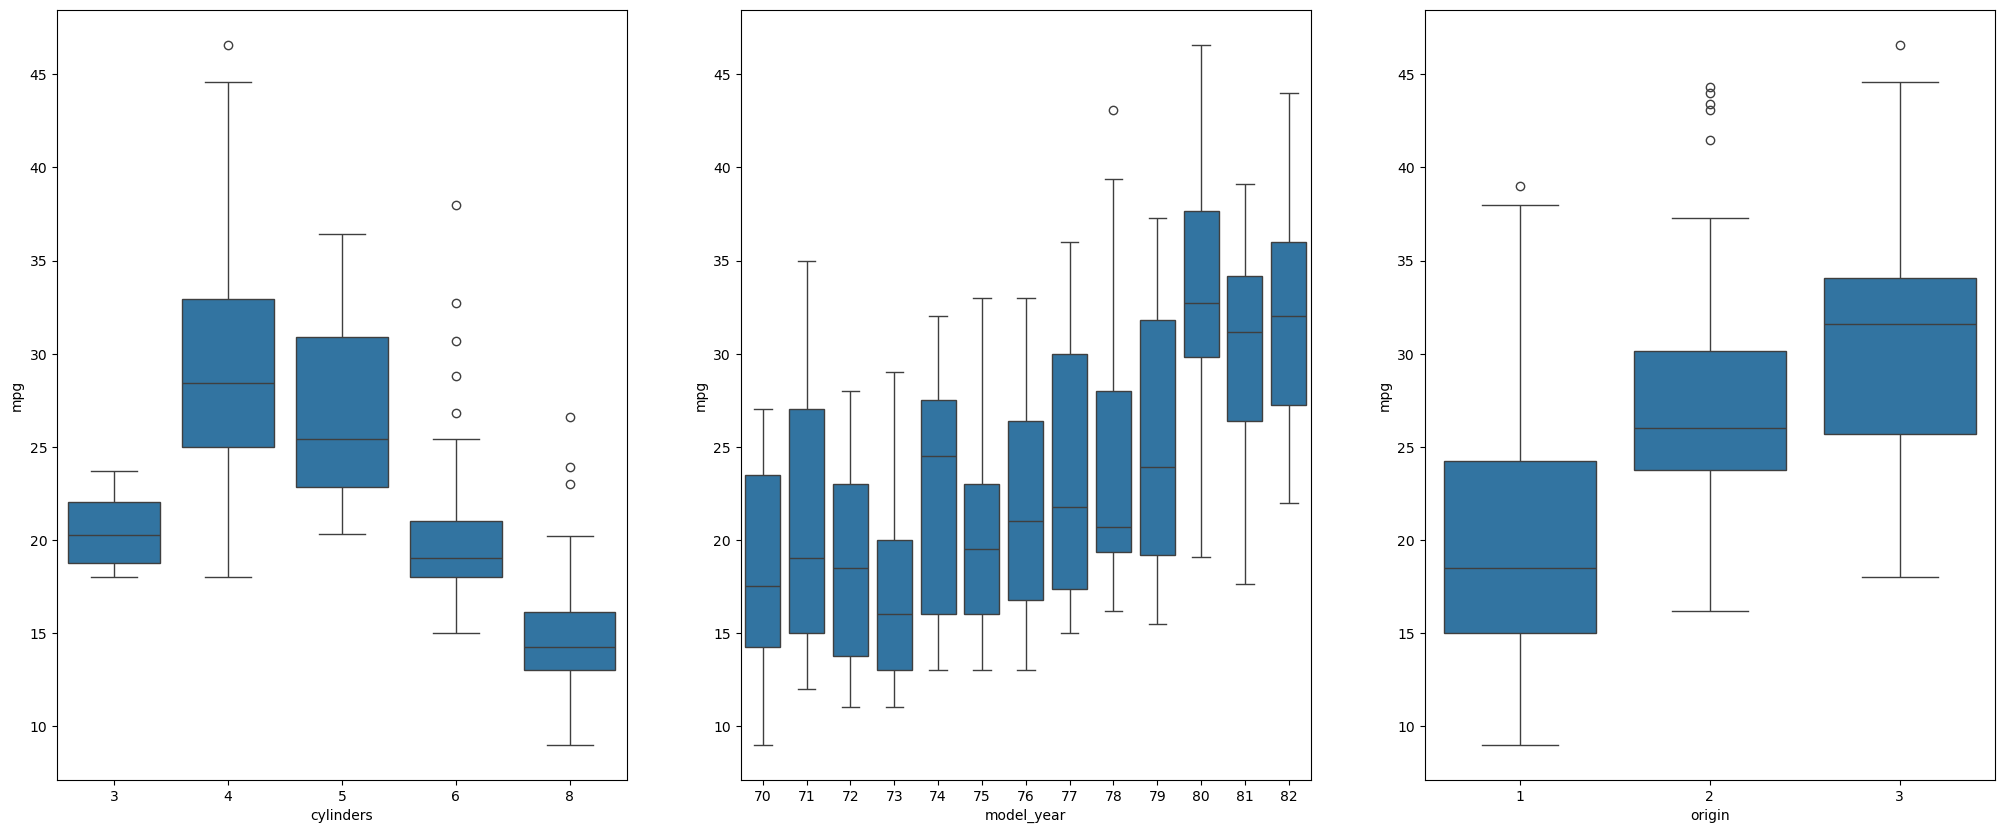

In [46]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(25, 10))
num = 0
axs = axs.flatten()

vars = ['cylinders', 'model_year', 'origin']

for feature in vars:
    sns.boxplot(data=data, x=feature, y= 'mpg', ax=axs[num])
    num += 1

##### Analysis:

- cylinders obviously have a good association with the target: more number of cylinders clearly means less fuel efficiency (which makes sense)
- origin: what captures my attention is that USA made cars have less efficiency, and I think there's a slight positive relationship as we can notice the median increase as we change the manufacturer's country
- I capture a slight upward trend as a big picture, but i don't think it's something representative 


In [47]:
# Create extra column 
counts = data['car_name'].value_counts()
top_n = 15
top_names = counts.head(top_n).index

data['car_name_grouped'] = data['car_name'].where(data['car_name'].isin(top_names), 'other')
data

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg,car_name_grouped
0,chevrolet,8,307.0,130.0,3504.0,12.0,70,1,18.0,chevrolet
1,buick,8,350.0,165.0,3693.0,11.5,70,1,15.0,buick
2,plymouth,8,318.0,150.0,3436.0,11.0,70,1,18.0,plymouth
3,amc,8,304.0,150.0,3433.0,12.0,70,1,16.0,amc
4,ford,8,302.0,140.0,3449.0,10.5,70,1,17.0,ford
...,...,...,...,...,...,...,...,...,...,...
393,ford,4,140.0,86.0,2790.0,15.6,82,1,27.0,ford
394,volkswagen,4,97.0,52.0,2130.0,24.6,82,2,44.0,volkswagen
395,dodge,4,135.0,84.0,2295.0,11.6,82,1,32.0,dodge
396,ford,4,120.0,79.0,2625.0,18.6,82,1,28.0,ford


['ford', 'chevrolet', 'plymouth', 'dodge', 'amc', 'toyota', 'datsun', 'volkswagen', 'buick', 'pontiac', 'honda', 'mazda', 'mercury', 'oldsmobile', 'peugeot', 'other']


<Axes: xlabel='car_name_grouped', ylabel='mpg'>

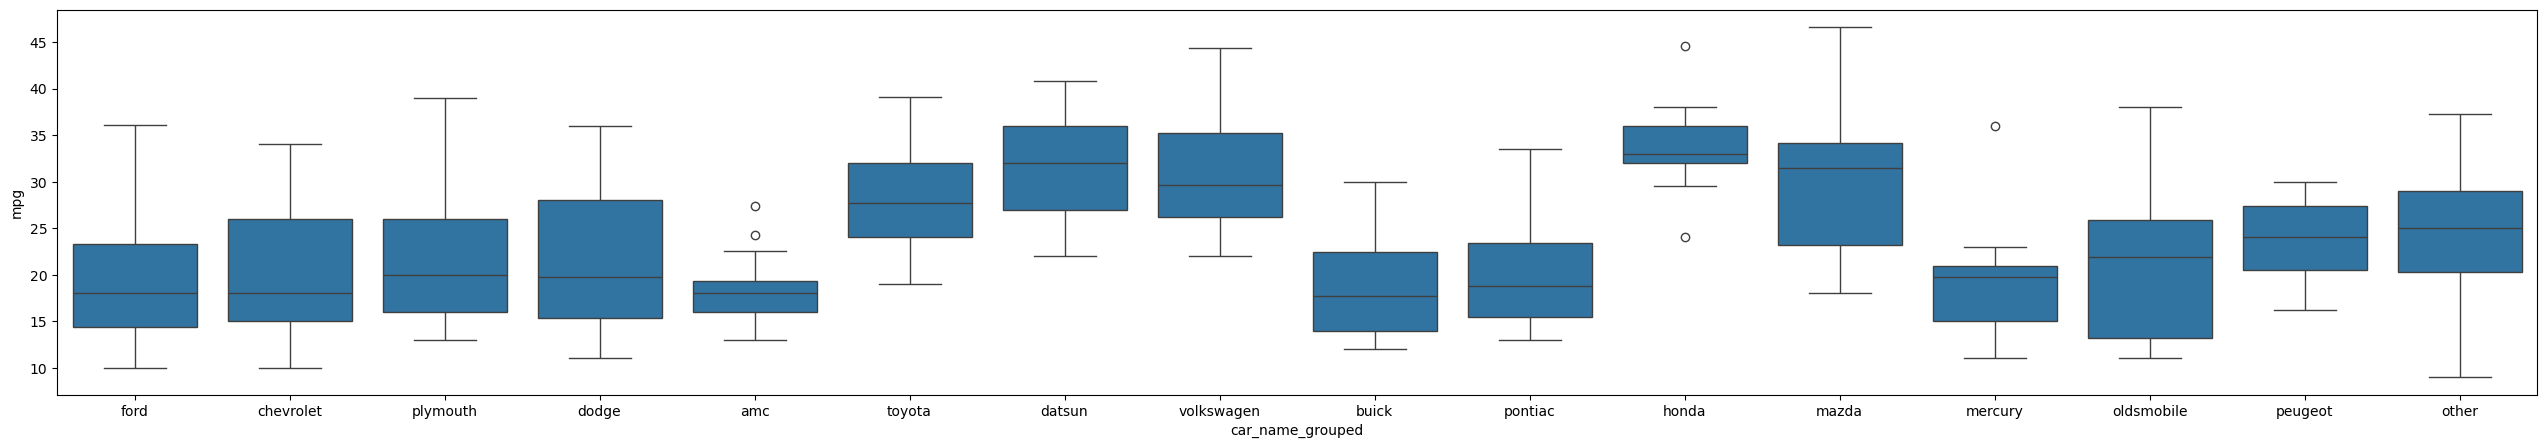

In [48]:
sort_values= list(top_names) + ['other']
print(sort_values)

plt.figure(figsize= (32, 5))
sns.boxplot(data= data, x='car_name_grouped', y='mpg', order=sort_values)

#### Analysis:

I don't see any relationship between car_names feature and the target, my attempt to use it won't happen since it shows almost no predictor capacity

In [49]:
# droping the extra column - was just for the previous analysis
data.drop(columns= 'car_name_grouped', inplace= True)
data

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,chevrolet,8,307.0,130.0,3504.0,12.0,70,1,18.0
1,buick,8,350.0,165.0,3693.0,11.5,70,1,15.0
2,plymouth,8,318.0,150.0,3436.0,11.0,70,1,18.0
3,amc,8,304.0,150.0,3433.0,12.0,70,1,16.0
4,ford,8,302.0,140.0,3449.0,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...,...
393,ford,4,140.0,86.0,2790.0,15.6,82,1,27.0
394,volkswagen,4,97.0,52.0,2130.0,24.6,82,2,44.0
395,dodge,4,135.0,84.0,2295.0,11.6,82,1,32.0
396,ford,4,120.0,79.0,2625.0,18.6,82,1,28.0


### Correlation Matrix

Since not every variable is continuous, I'll use the Spearman correlation coefficient method, which relies on ranks, instead of the tradicional Pearson coefficient. 
Note: I'll take out of this matrix car_name and origin features since they're categorical.

<Axes: >

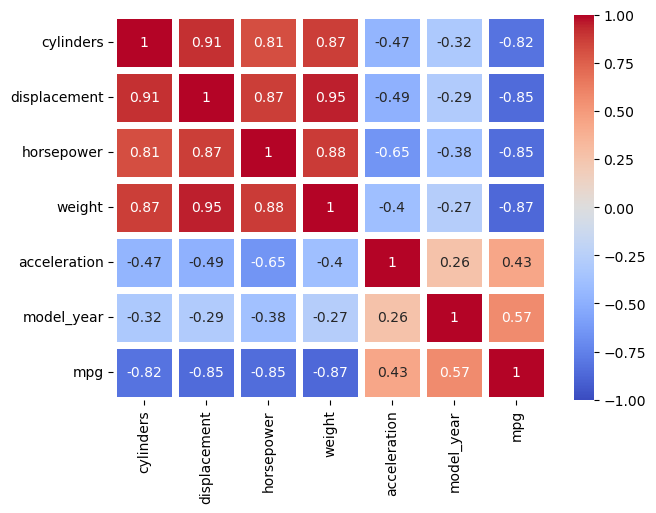

In [50]:
plt.figure(figsize= ( 7, 5))
corr = data.drop(columns= ['car_name', 'origin']).corr(method='spearman')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1)


<Axes: title={'center': 'Original Data'}>

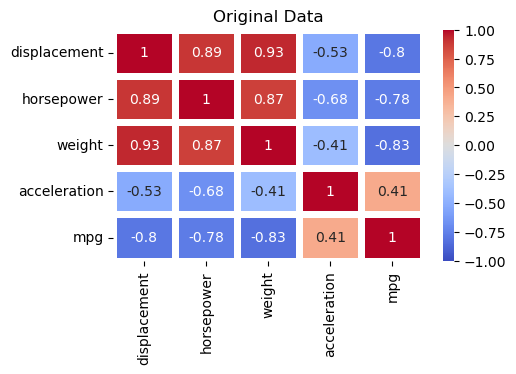

In [51]:
plt.figure(figsize=(5, 3))
plt.title("Original Data")
corr = data[['displacement', 'horsepower', 'weight', 'acceleration', 'mpg']].corr(method='pearson')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1)

<Axes: title={'center': 'Log Transformed Data'}>

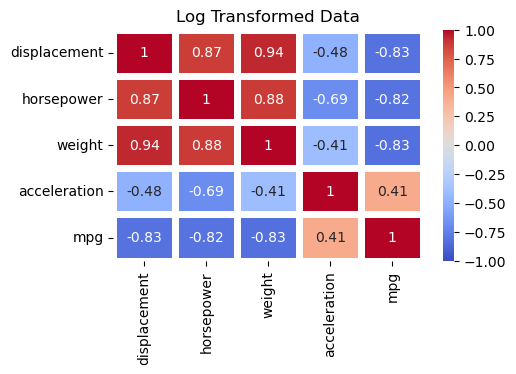

In [52]:
plt.figure(figsize=(5, 3))
plt.title("Log Transformed Data")
corr = data_transf[['displacement', 'horsepower', 'weight', 'acceleration', 'mpg']].corr(method='pearson')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1)

Plotting the 2 transformed features Pearson correlation againts the target (since Spearman's correlation uses ranks/positions, the log transformation wouldn't produce any result), we can notice that there's a very slight increase in both features with the target, contraty to my previously belief

#### Features-Target Analysis

- As we already checked before with the scatterplot matrix, the features with most predicting capacity are weight, displacement, horsepower and cylinders. There are a few little differences between Spearman and Person results, but nothing representative. 
- At the same time, we can confirm that features horsepower, displacement and weight have a high correlation between each other! Later on in the feature selection step, we need to have this in consideration

#### Feature-Target relationship outliers

After the correlation analysis, I want to look again at the outliers but in a feature-taret relationship scenario, speficially for the high correlated features.

In [53]:
from scipy import stats

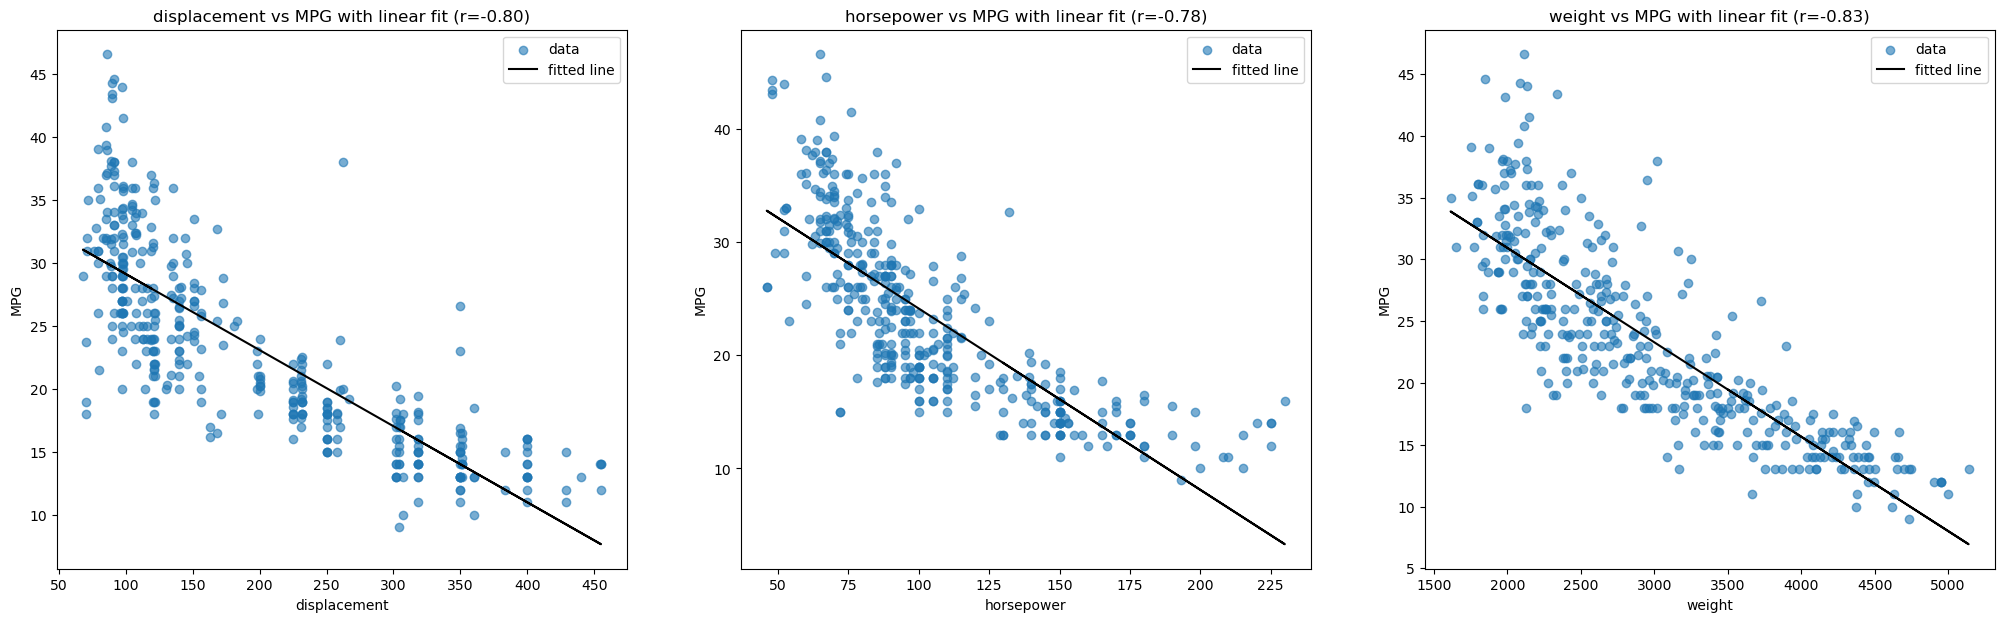

In [54]:
vars = ['displacement', 'horsepower', 'weight']

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(25, 7))
num = 0
axs = axs.flatten()

for feature in vars:
    slope, intercept, r, p, se  = stats.linregress(x=data[feature], y=data['mpg'])

    axs[num].scatter(data[feature], data['mpg'], alpha=0.6, label='data')
    axs[num].plot(data[feature], intercept + slope * data[feature], color='black', label='fitted line')
    axs[num].set_xlabel(feature)
    axs[num].set_ylabel('MPG')
    axs[num].set_title(f'{feature} vs MPG with linear fit (r={r:.2f})')
    axs[num].legend()
    num += 1


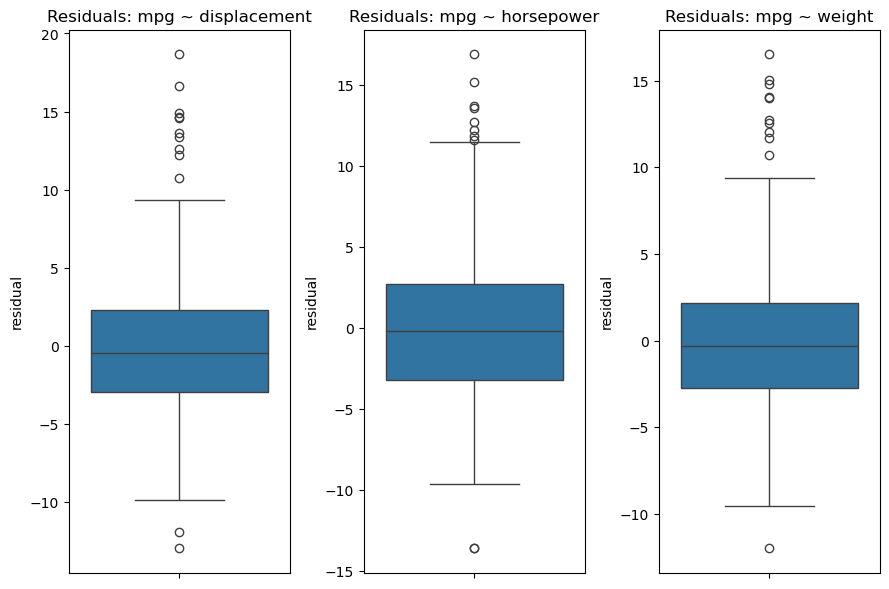

In [55]:
vars = ['displacement', 'horsepower', 'weight']

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9, 6))
num = 0
axs = axs.flatten()

for feature in vars:
    slope, intercept, r, p, se  = stats.linregress(x=data[feature], y=data['mpg'])
    data['predicted_mpg'] = slope * data[feature] + intercept
    data['residual'] = data['mpg'] - data['predicted_mpg']

    sns.boxplot(y=data['residual'], ax=axs[num])
    axs[num].set_title(f'Residuals: mpg ~ {feature}')
    num += 1
plt.tight_layout()


##### For the Transformed Dataset

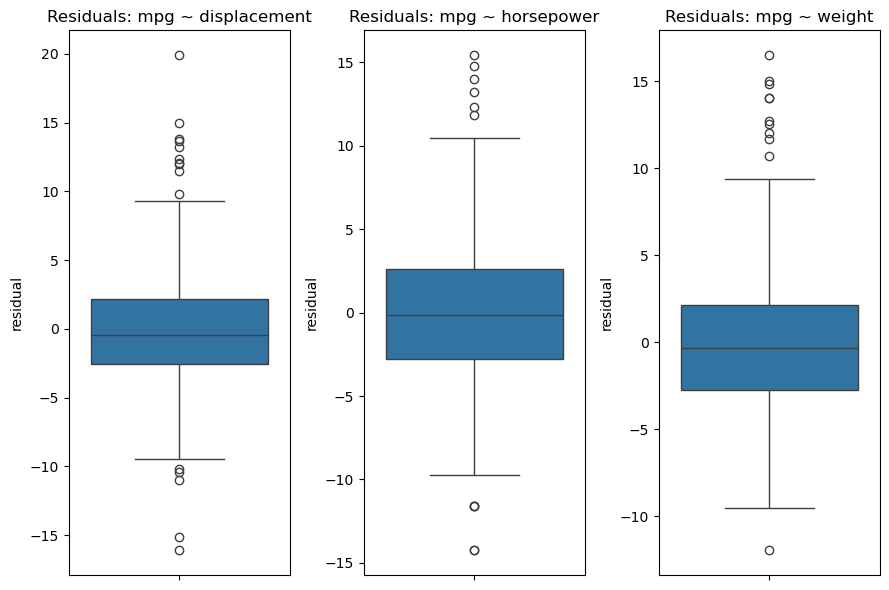

In [56]:
vars = ['displacement', 'horsepower', 'weight']

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9, 6))
num = 0
axs = axs.flatten()

for feature in vars:
    slope, intercept, r, p, se  = stats.linregress(x=data_transf[feature], y=data_transf['mpg'])
    data_transf['predicted_mpg'] = slope * data_transf[feature] + intercept
    data_transf['residual'] = data['mpg'] - data_transf['predicted_mpg']

    sns.boxplot(y=data_transf['residual'], ax=axs[num])
    axs[num].set_title(f'Residuals: mpg ~ {feature}')
    num += 1
plt.tight_layout()

By analyzing the boxplots and the linear regression plot, we can confidently say that thart are indeed, outliers when we consider a feature-target type of relatonship. Let's find out which rows are.  

In [57]:
data.shape

(389, 11)

In [58]:
outlier_rows = []

vars = ['displacement', 'horsepower', 'weight']

print(f'Transformed Data Outliers:')

for feature in vars:
    slope, intercept, r, p, se  = stats.linregress(x=data_transf[feature], y=data_transf['mpg'])
    data_transf['predicted_mpg'] = slope * data_transf[feature] + intercept
    data_transf['residual'] = data['mpg'] - data_transf['predicted_mpg']
    data_out = data_transf['residual'] 

    # note to myself: in each loop, which means for each feature residuals, I have to calculate de IQR and its outliers, bcs each feature residuals have a different distribution and values
    q1 = data_out.quantile(0.25)
    q3 = data_out.quantile(0.75)
    iqr = q3 - q1
    upper_lim = q3 + 1.5*iqr
    lower_lim = q1 - 1.5* iqr
    total_out = data_out[(data_out > upper_lim) | (data_out < lower_lim)] 
    perc = (total_out.size / data_transf[variable].size) *100

    if total_out.size > 0:
        print(f'\n{feature} number of outliers = {total_out.size}')
        print(f'{feature} percentage of outliers = {round(perc)}%')

        df_out = data_transf.loc[total_out.index]
        df_out['outlier_variable'] = feature
        df_out['outlier_value'] = total_out
        df_out['upper_lim'] = upper_lim
        df_out['lower_lim'] = lower_lim
        outlier_rows.append(df_out)
        
    else: 
        print(f'\n{feature} as no outliers')  
        
df_out_trans = pd.concat(outlier_rows)
df_out_trans.sort_values(by= ['outlier_variable', 'mpg'], ascending= False, inplace=True)
df_out_trans

Transformed Data Outliers:

displacement number of outliers = 15
displacement percentage of outliers = 4%

horsepower number of outliers = 11
horsepower percentage of outliers = 3%

weight number of outliers = 11
weight percentage of outliers = 3%


,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg,predicted_mpg,residual,outlier_variable,outlier_value,upper_lim,lower_lim
322,mazda,4,4.465908,4.189655,2110.0,17.9,80,3,46.6,30.084350,16.515650,weight,16.515650,9.534552,-10.141848
329,honda,4,4.521789,4.219508,1850.0,13.8,80,3,44.6,32.069407,12.530593,weight,12.530593,9.534552,-10.141848
325,volkswagen,4,4.510860,3.891820,2085.0,21.7,80,2,44.3,30.275221,14.024779,weight,14.024779,9.534552,-10.141848
394,volkswagen,4,4.584967,3.970292,2130.0,24.6,82,2,44.0,29.931654,14.068346,weight,14.068346,9.534552,-10.141848
326,volkswagen,4,4.510860,3.891820,2335.0,23.7,80,2,43.4,28.366513,15.033487,weight,15.033487,9.534552,-10.141848
244,volkswagen,4,4.510860,3.891820,1985.0,21.5,78,2,43.1,31.038704,12.061296,weight,12.061296,9.534552,-10.141848
309,volkswagen,4,4.595120,4.343805,2144.0,14.7,80,2,41.5,29.824766,11.675234,weight,11.675234,9.534552,-10.141848
324,datsun,4,4.454347,4.189655,2110.0,19.2,80,3,40.8,30.084350,10.715650,weight,10.715650,9.534552,-10.141848
387,oldsmobile,6,5.572154,4.454347,3015.0,17.0,82,1,38.0,23.174826,14.825174,weight,14.825174,9.534552,-10.141848
327,audi,5,4.804021,4.219508,2950.0,19.9,80,2,36.4,23.671090,12.728910,weight,12.728910,9.534552,-10.141848


In [59]:
outlier_rows = []

vars = ['displacement', 'horsepower', 'weight']

print(f"Original Data Outliers:")

for feature in vars:
    slope, intercept, r, p, se  = stats.linregress(x=data[feature], y=data['mpg'])
    data['predicted_mpg'] = slope * data[feature] + intercept
    data['residual'] = data['mpg'] - data['predicted_mpg']
    data_out = data['residual'] 

    # note to myself: in each loop, which means for each feature residuals, I have to calculate de IQR and its outliers, bcs each feature residuals have a different distribution and values
    q1 = data_out.quantile(0.25)
    q3 = data_out.quantile(0.75)
    iqr = q3 - q1
    upper_lim = q3 + 1.5*iqr
    lower_lim = q1 - 1.5* iqr
    total_out = data_out[(data_out > upper_lim) | (data_out < lower_lim)] 
    perc = (total_out.size / data[variable].size) *100

    if total_out.size > 0:
        print(f'\n{feature} number of outliers = {total_out.size}')
        print(f'{feature} percentage of outliers = {round(perc)}%')

        df_out = data.loc[total_out.index]
        df_out['outlier_variable'] = feature
        df_out['outlier_value'] = total_out
        df_out['upper_lim'] = upper_lim
        df_out['lower_lim'] = lower_lim
        outlier_rows.append(df_out)
        
    else: 
        print(f'\n{feature} as no outliers')  
        
df_out_ori = pd.concat(outlier_rows)
df_out_ori.sort_values(by= ['outlier_variable', 'mpg'], ascending= False, inplace=True)
df_out_ori

Original Data Outliers:

displacement number of outliers = 12
displacement percentage of outliers = 3%

horsepower number of outliers = 10
horsepower percentage of outliers = 3%

weight number of outliers = 11
weight percentage of outliers = 3%


,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg,predicted_mpg,residual,outlier_variable,outlier_value,upper_lim,lower_lim
322,mazda,4,86.0,65.0,2110.0,17.9,80,3,46.6,30.084350,16.515650,weight,16.515650,9.534552,-10.141848
329,honda,4,91.0,67.0,1850.0,13.8,80,3,44.6,32.069407,12.530593,weight,12.530593,9.534552,-10.141848
325,volkswagen,4,90.0,48.0,2085.0,21.7,80,2,44.3,30.275221,14.024779,weight,14.024779,9.534552,-10.141848
394,volkswagen,4,97.0,52.0,2130.0,24.6,82,2,44.0,29.931654,14.068346,weight,14.068346,9.534552,-10.141848
326,volkswagen,4,90.0,48.0,2335.0,23.7,80,2,43.4,28.366513,15.033487,weight,15.033487,9.534552,-10.141848
244,volkswagen,4,90.0,48.0,1985.0,21.5,78,2,43.1,31.038704,12.061296,weight,12.061296,9.534552,-10.141848
309,volkswagen,4,98.0,76.0,2144.0,14.7,80,2,41.5,29.824766,11.675234,weight,11.675234,9.534552,-10.141848
324,datsun,4,85.0,65.0,2110.0,19.2,80,3,40.8,30.084350,10.715650,weight,10.715650,9.534552,-10.141848
387,oldsmobile,6,262.0,85.0,3015.0,17.0,82,1,38.0,23.174826,14.825174,weight,14.825174,9.534552,-10.141848
327,audi,5,121.0,67.0,2950.0,19.9,80,2,36.4,23.671090,12.728910,weight,12.728910,9.534552,-10.141848


##### Important note: there are duplicated rows in the last 2 dataframes, because the same datapoint can be an outlier for different feature-target relationship. An example: the first row is considered an outlier 3 times because for the 3 features analyzed, it has a value higher than usual.  I'm gonna keep it that way, because if a row isn't considered an outlier based on the condition (see next cell) for one feature, but it is for another, then that outlier must be eliminated. Basically, duplicated rows are completely eliminated only if for each variable, they aren't considered an outlier.  

##### Outliers treatment

Most of these outliers I'm gonna drop, but there are a few - when the residual value is very close to the upper or lower limit - that I want to keep, since they don't offer such of a influence. 
I'm gonna use a 1 value range to decide to include or not. 

In [60]:
# for the original data 
high_out = df_out_ori['outlier_value'] > df_out_ori['upper_lim']
low_out = df_out_ori['outlier_value'] < df_out_ori['lower_lim']

borderline = (
    (high_out & (df_out_ori['outlier_value'] - 1 > df_out_ori['upper_lim'])) |
    (low_out & (df_out_ori['outlier_value'] + 1 < df_out_ori['lower_lim']))
)

rows_eliminate = df_out_ori[borderline] #still containing the duplicated rows
unique_outlier_rows = rows_eliminate.index.nunique() #now I only have the unique values 

print(f"number of outliers to eliminate: {unique_outlier_rows}, which represent {round((unique_outlier_rows / data.shape[0])*100, 0)}% of our original dataset")

number of outliers to eliminate: 17, which represent 4.0% of our original dataset


In [61]:
print(f"Before outlier drop, original dataset number of rows: {data.shape[0]}")
out_index = rows_eliminate.index
data.drop(index= out_index, inplace=True)
print(f"\nAfter outlier drop, original dataset number of rows: {data.shape[0]}")

Before outlier drop, original dataset number of rows: 389

After outlier drop, original dataset number of rows: 372


In [62]:
# for the transformed data 
high_out = df_out_trans['outlier_value'] > df_out_trans['upper_lim']
low_out = df_out_trans['outlier_value'] < df_out_trans['lower_lim']

borderline = (
    (high_out & (df_out_trans['outlier_value'] - 1 > df_out_trans['upper_lim'])) |
    (low_out & (df_out_trans['outlier_value'] + 1 < df_out_trans['lower_lim']))
)

rows_eliminate = df_out_trans[borderline]
unique_outlier_rows = rows_eliminate.index.nunique() 

print(f"number of outliers to eliminate: {unique_outlier_rows}, which represent {round((unique_outlier_rows / data.shape[0])*100, 0)}% of our original dataset")

number of outliers to eliminate: 18, which represent 5.0% of our original dataset


In [63]:
print(f"Before outlier drop, transnformed dataset number of rows: {data_transf.shape[0]}")
out_index = rows_eliminate.index
data_transf.drop(index= out_index, inplace=True)
print(f"\nAfter outlier drop, transformed dataset number of rows: {data_transf.shape[0]}")

Before outlier drop, transnformed dataset number of rows: 389

After outlier drop, transformed dataset number of rows: 371


##### Wrap-Up: Until now, we did the descriptive statistic phase, we looked at our data behavior, we have 2 datasets after a logarithmic transformation in the horsepower and displacement features, which means that for the regression model, we'll train 2 different models - 1 model per dataset -, and see which one performs better. We also did take care of any univariate and multivariate outliers. 

# Data Preparation

## Checking Missing Values

we already dealt with it, but just to make sure the data is 100% ready to build our models

In [64]:
ori_data_miss = data.isnull().sum().sum()
trans_data_miss = data_transf.isnull().sum().sum()
print(f"Number of missing values in our original dataset is: {ori_data_miss}")
print(f"Number of missing values in our trasnformed dataset is: {trans_data_miss}")

Number of missing values in our original dataset is: 0
Number of missing values in our trasnformed dataset is: 0


## Variables Drop

In [65]:
data.dtypes

car_name          string
cylinders          int64
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year         int64
origin             int64
mpg              float64
predicted_mpg    float64
residual         float64
dtype: object

In [66]:
data.drop(columns=['car_name', 'predicted_mpg', 'residual'], inplace=True)
data_transf.drop(columns = ['car_name', 'predicted_mpg', 'residual'], inplace=True)
data

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,307.0,130.0,3504.0,12.0,70,1,18.0
1,8,350.0,165.0,3693.0,11.5,70,1,15.0
2,8,318.0,150.0,3436.0,11.0,70,1,18.0
3,8,304.0,150.0,3433.0,12.0,70,1,16.0
4,8,302.0,140.0,3449.0,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
392,4,151.0,90.0,2950.0,17.3,82,1,27.0
393,4,140.0,86.0,2790.0,15.6,82,1,27.0
395,4,135.0,84.0,2295.0,11.6,82,1,32.0
396,4,120.0,79.0,2625.0,18.6,82,1,28.0


In [67]:
data_transf

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,5.730100,4.875197,3504.0,12.0,70,1,18.0
1,8,5.860786,5.111988,3693.0,11.5,70,1,15.0
2,8,5.765191,5.017280,3436.0,11.0,70,1,18.0
3,8,5.720312,5.017280,3433.0,12.0,70,1,16.0
4,8,5.713733,4.948760,3449.0,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
392,4,5.023881,4.510860,2950.0,17.3,82,1,27.0
393,4,4.948760,4.465908,2790.0,15.6,82,1,27.0
395,4,4.912655,4.442651,2295.0,11.6,82,1,32.0
396,4,4.795791,4.382027,2625.0,18.6,82,1,28.0


# Splitting the Dataset into Training set and Test set 

### Importance of this step

Dividing the data into a train set and a test set is crucial because this is the way we have to train the model with the train set, and then evaluate how the model performs in unseen data. When we build a model, the main goal of it is to actually have the capacity to make accurate predictions for different types of inputs (data), I don't want a model that just do good predictions on the data he was built on. Otherwise it lacks the capacity of generalizing, which is what I just described. 

#### I'm gonna split into train-test sets because the datasize is small to use  a train-validation-test split. I'll also use a cross-validation method to improve models' predictive capacity

In [68]:
from sklearn.model_selection import train_test_split
data_train, data_test = train_test_split(data, test_size= 0.2, random_state=789)

In [69]:
data_transf_train, data_transf_test = train_test_split(data_transf, test_size= 0.2, random_state=789)

In [70]:
print(f"Original dataset 20% = {data.shape[0]*0.2}")
print(f"data_train dimension is: {data_train.shape}")
print(f"data_test dimension is: {data_test.shape}")

print(f"\nTransformed dataset 20% = {data_transf.shape[0]*0.2}")
print(f"data_transf_train dimension is: {data_transf_train.shape}")
print(f"data_transf_test dimension is: {data_transf_test.shape}")

Original dataset 20% = 74.4
data_train dimension is: (297, 8)
data_test dimension is: (75, 8)

Transformed dataset 20% = 74.2
data_transf_train dimension is: (296, 8)
data_transf_test dimension is: (75, 8)


In [71]:
data_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
61,4,122.0,86.0,2226.0,16.5,72,1,21.0
47,6,250.0,100.0,3282.0,15.0,71,1,19.0
48,6,250.0,88.0,3139.0,14.5,71,1,18.0
279,4,98.0,68.0,2135.0,16.6,78,3,29.5
56,4,91.0,70.0,1955.0,20.5,71,1,26.0
...,...,...,...,...,...,...,...,...
237,4,98.0,63.0,2051.0,17.0,77,1,30.5
353,4,105.0,74.0,2190.0,14.2,81,2,33.0
220,4,85.0,70.0,1945.0,16.8,77,3,33.5
150,4,108.0,93.0,2391.0,15.5,74,3,26.0


In [72]:
data_test

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
299,4,141.0,71.0,3190.0,24.8,79,2,27.2
105,8,360.0,170.0,4654.0,13.0,73,1,13.0
338,4,135.0,84.0,2490.0,15.7,81,1,27.2
109,4,140.0,72.0,2401.0,19.5,73,1,21.0
320,4,119.0,92.0,2434.0,15.0,80,3,37.0
...,...,...,...,...,...,...,...,...
274,5,131.0,103.0,2830.0,15.9,78,2,20.3
65,8,351.0,153.0,4129.0,13.0,72,1,14.0
192,6,250.0,105.0,3353.0,14.5,76,1,22.0
153,6,250.0,105.0,3459.0,16.0,75,1,18.0


# Feature Analysis/Selection, Regression Models and Model Evaluation

In this section I'm gonna build 3 different regression models:
- Linear Regression
- Decision Tree
- Random Forest 

For each model I'll do feature selection based on:
- Correlation Analysis and Scatterplots 
- Feature Contribution: I'll use SHAP method on the 3 models
  

And to measure model performance I'll use 3 measures:
- r squared (r2)
- mean absolute error (MAE)
- root mean squared error (RMSE)

## Pre-Model Training Feature Selection

Before training any of the models, I want to decide what to do with features that are highly correlated with each other as just saw in the EDA: weight, horsepower, displacement and cylinders. But because after the last correlation matrix I did a second outlier tretament, for the sake of being statistically precise, let's plot another correlation matrix in our 2 datasets.  

<Axes: title={'center': 'Log Transformed Data - Pearson'}>

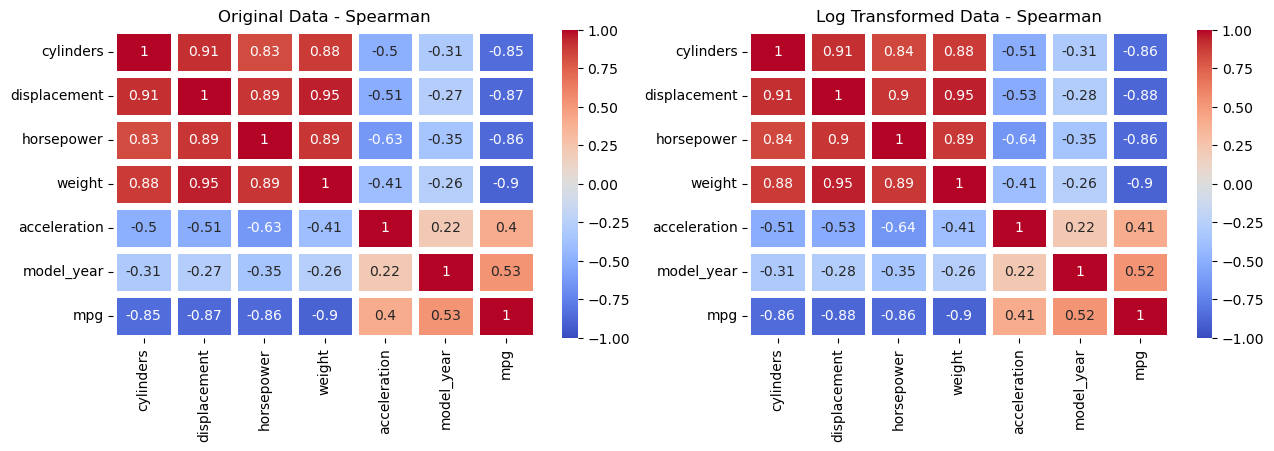

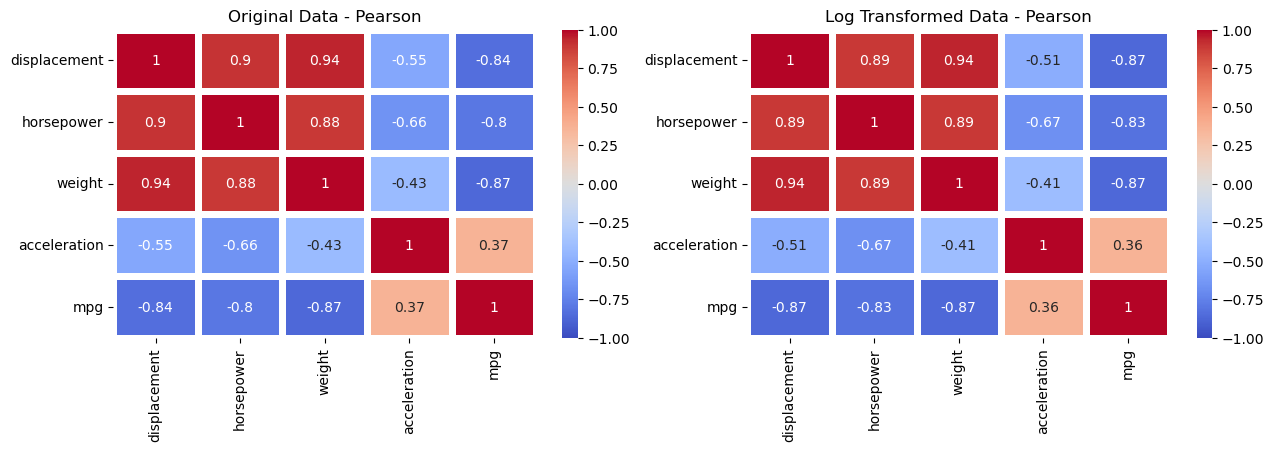

In [74]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))
num = 0
axs = axs.flatten()

axs[num].set_title("Original Data - Spearman")
corr = data_train.drop(columns= ['origin']).corr(method='spearman')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[num])
num += 1

axs[num].set_title("Log Transformed Data - Spearman")
corr = data_transf_train.drop(columns= ['origin']).corr(method='spearman')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[num])
num += 1


fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))
num = 0
axs = axs.flatten()

axs[num].set_title("Original Data - Pearson")
corr = data_train[['displacement', 'horsepower', 'weight', 'acceleration', 'mpg']].corr(method='pearson')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[num])
num += 1

axs[num].set_title("Log Transformed Data - Pearson")
corr = data_transf_train[['displacement', 'horsepower', 'weight', 'acceleration', 'mpg']].corr(method='pearson')
sns.heatmap(corr, annot=True, linewidths=5, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[num])



### This is the process to deal with the features before training the models:

- Linear Regression: I'm gonna drop cylinders, horsepower and displacement, since in linear regression models that leads to redundancy, it does't increse the model predictive capacity, and weight keeps getitng the high correlation values with the target. 
- Decision Tree: I'm gonna keep all features, then use SHAP method and/or Gini Index to further understand feature importance in the model, since decision trees can handle multicollinearity
- Random Forest: I'm gonna drop the same features as in the linear regression model, because, even though a random forest can use highly correlated predictors to predict, i.e., it doesn't affect the prediction capacity, remember that our focus here is not to only get the highest possible accuracy, we are also looking for interpretability. And the multicollinearity will dificult the interpretability a lot, because I can't use feature importance or even permutation feature importance to do feature selection.   

## Encoding and Feature-Target Separation Context

I splitted my data into train-test to do a correlation analysis and the feature selection, avoiding data lekeage. After this I want to drop some columns, and to facilitate all these previous mentioned processes I needed the data in a dataframe format, that's the reason why I still have the feature and targets in together, as also theorigin variable not labeled. 

## Linear Regression Model


With the linear regression model I want to build a base for interpretability - understand how each variable affects the fuel efficiency -, and for that reason, I won't be using the transformed data, since the log transformation have a non-linear characteristic, so it would've impact the interpretability. I'm also ok with this decision because I just checked that there's no big difference in the correlations between the transformed features and the target vs the original ones, so the trade-off for a possible little increase in the accuracy and interpretability part doesn't benefits the model. 

### Droping the features 

In [75]:
data_train_lr = data_train.drop(columns= ['cylinders', 'horsepower', 'displacement'])
data_train_lr

,weight,acceleration,model_year,origin,mpg
61,2226.0,16.5,72,1,21.0
47,3282.0,15.0,71,1,19.0
48,3139.0,14.5,71,1,18.0
279,2135.0,16.6,78,3,29.5
56,1955.0,20.5,71,1,26.0
...,...,...,...,...,...
237,2051.0,17.0,77,1,30.5
353,2190.0,14.2,81,2,33.0
220,1945.0,16.8,77,3,33.5
150,2391.0,15.5,74,3,26.0


In [76]:
data_test_lr = data_test.drop(columns= ['cylinders', 'horsepower', 'displacement'])
data_test_lr

,weight,acceleration,model_year,origin,mpg
299,3190.0,24.8,79,2,27.2
105,4654.0,13.0,73,1,13.0
338,2490.0,15.7,81,1,27.2
109,2401.0,19.5,73,1,21.0
320,2434.0,15.0,80,3,37.0
...,...,...,...,...,...
274,2830.0,15.9,78,2,20.3
65,4129.0,13.0,72,1,14.0
192,3353.0,14.5,76,1,22.0
153,3459.0,16.0,75,1,18.0


### Features's separation from target

#### Train Dataset

In [247]:
# original dataset
x1_train = data_train_lr.iloc[:, :-1].values 
y1_train = data_train.iloc[:, -1].values

#### Test Dataset

In [248]:
# original dataset
x1_test = data_test_lr.iloc[:, :-1].values
y1_test_lr = data_test.iloc[:, -1].values

In [249]:
x1_train

array([[2.226e+03, 1.650e+01, 7.200e+01, 1.000e+00],
       [3.282e+03, 1.500e+01, 7.100e+01, 1.000e+00],
       [3.139e+03, 1.450e+01, 7.100e+01, 1.000e+00],
       ...,
       [1.945e+03, 1.680e+01, 7.700e+01, 3.000e+00],
       [2.391e+03, 1.550e+01, 7.400e+01, 3.000e+00],
       [1.834e+03, 1.900e+01, 7.100e+01, 2.000e+00]], shape=(297, 4))

In [250]:
x1_test

array([[3.190e+03, 2.480e+01, 7.900e+01, 2.000e+00],
       [4.654e+03, 1.300e+01, 7.300e+01, 1.000e+00],
       [2.490e+03, 1.570e+01, 8.100e+01, 1.000e+00],
       [2.401e+03, 1.950e+01, 7.300e+01, 1.000e+00],
       [2.434e+03, 1.500e+01, 8.000e+01, 3.000e+00],
       [4.325e+03, 1.220e+01, 7.700e+01, 1.000e+00],
       [3.245e+03, 1.540e+01, 7.900e+01, 1.000e+00],
       [3.840e+03, 1.540e+01, 7.900e+01, 1.000e+00],
       [2.190e+03, 1.410e+01, 7.700e+01, 2.000e+00],
       [2.228e+03, 1.400e+01, 7.100e+01, 3.000e+00],
       [2.255e+03, 1.770e+01, 7.600e+01, 1.000e+00],
       [2.075e+03, 1.590e+01, 7.700e+01, 1.000e+00],
       [2.565e+03, 1.360e+01, 7.600e+01, 1.000e+00],
       [3.535e+03, 1.920e+01, 7.800e+01, 1.000e+00],
       [2.634e+03, 1.300e+01, 7.100e+01, 1.000e+00],
       [2.385e+03, 1.290e+01, 8.100e+01, 1.000e+00],
       [3.399e+03, 1.100e+01, 7.300e+01, 1.000e+00],
       [4.735e+03, 1.100e+01, 7.300e+01, 1.000e+00],
       [3.155e+03, 1.820e+01, 7.800e+01, 1.000

### Categorical Variable Encoding

In [251]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [-1])], remainder='passthrough')
X1_train = np.array(ct.fit_transform(x1_train))
X1_test_lr = np.array(ct.fit_transform(x1_test)) 


In [252]:
print(X1_train)

[[0.000e+00 0.000e+00 2.226e+03 1.650e+01 7.200e+01]
 [0.000e+00 0.000e+00 3.282e+03 1.500e+01 7.100e+01]
 [0.000e+00 0.000e+00 3.139e+03 1.450e+01 7.100e+01]
 ...
 [0.000e+00 1.000e+00 1.945e+03 1.680e+01 7.700e+01]
 [0.000e+00 1.000e+00 2.391e+03 1.550e+01 7.400e+01]
 [1.000e+00 0.000e+00 1.834e+03 1.900e+01 7.100e+01]]


In [253]:
print(X1_test_lr)

[[1.000e+00 0.000e+00 3.190e+03 2.480e+01 7.900e+01]
 [0.000e+00 0.000e+00 4.654e+03 1.300e+01 7.300e+01]
 [0.000e+00 0.000e+00 2.490e+03 1.570e+01 8.100e+01]
 [0.000e+00 0.000e+00 2.401e+03 1.950e+01 7.300e+01]
 [0.000e+00 1.000e+00 2.434e+03 1.500e+01 8.000e+01]
 [0.000e+00 0.000e+00 4.325e+03 1.220e+01 7.700e+01]
 [0.000e+00 0.000e+00 3.245e+03 1.540e+01 7.900e+01]
 [0.000e+00 0.000e+00 3.840e+03 1.540e+01 7.900e+01]
 [1.000e+00 0.000e+00 2.190e+03 1.410e+01 7.700e+01]
 [0.000e+00 1.000e+00 2.228e+03 1.400e+01 7.100e+01]
 [0.000e+00 0.000e+00 2.255e+03 1.770e+01 7.600e+01]
 [0.000e+00 0.000e+00 2.075e+03 1.590e+01 7.700e+01]
 [0.000e+00 0.000e+00 2.565e+03 1.360e+01 7.600e+01]
 [0.000e+00 0.000e+00 3.535e+03 1.920e+01 7.800e+01]
 [0.000e+00 0.000e+00 2.634e+03 1.300e+01 7.100e+01]
 [0.000e+00 0.000e+00 2.385e+03 1.290e+01 8.100e+01]
 [0.000e+00 0.000e+00 3.399e+03 1.100e+01 7.300e+01]
 [0.000e+00 0.000e+00 4.735e+03 1.100e+01 7.300e+01]
 [0.000e+00 0.000e+00 3.155e+03 1.820e+01 7.80

#### Checking the datasets

In [254]:
print(f"x1 shape:{X1_train.shape}")
print(f"y1 shape:{y1_train.shape}")

x1 shape:(297, 5)
y1 shape:(297,)


In [255]:
print(f"x1 shape:{X1_test_lr.shape}")
print(f"y1 shape:{y1_test_lr.shape}")

x1 shape:(75, 5)
y1 shape:(75,)


### Training a Multiple Linear Regression model - X1_train dataset

### Leave One Out Cross Validation
I'm gonna use this cross-validation method because the dataset is so small, I think it's the right approach compared to doing more splits in an already small data.
This cross-validation method will give robustness to our validation, before doing the final test. 

In [86]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()

y1_predict_loo = cross_val_predict(regressor, X1_train, y1_train, cv=loo)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

predict_loo_r2 = r2_score(y1_train, y1_predict_loo)
predict_loo_mae = mean_absolute_error(y1_train, y1_predict_loo)
predict_loo_rmse = np.sqrt(np.mean(np.square(y1_train - y1_predict_loo)))

print(f"LOOCV overall R²: {predict_loo_r2:.4f}")
print(f"LOOCV overall MAE: {predict_loo_mae:.2f}")
print(f"LOOCV overall RMSE: {predict_loo_rmse:.2f}")

LOOCV overall R²: 0.8468
LOOCV overall MAE: 2.24
LOOCV overall RMSE: 2.83


### SHAP method
##### I already did a cross-validation with all reasonable features, now I want to try to do some feature selection using SHAP (SHapley Additive exPlanations) method, and I'm gonna guide the decision to drop a feature or not on our 3 measures - r squared, mean absolute error and mean absolute percentage error

SHAP method allows me to better understand the importance of each feature, by giving me the value of how much each feature contributes to the prediction based on each instance. 

In [87]:
# Get feature names after one-hot encoding
feature_names = ct.get_feature_names_out()

# Print feature names
print(f"train dataset column names after 'origin' encoding: {feature_names}")

train dataset column names after 'origin' encoding: ['encoder__x3_2.0' 'encoder__x3_3.0' 'remainder__x0' 'remainder__x1'
 'remainder__x2']


In [88]:
x1_train_col_names = data_train_lr.iloc[:, :-1].columns
print(f"\ntrain dataset column names before 'origin' encoding: {x1_train_col_names}")


train dataset column names before 'origin' encoding: Index(['weight', 'acceleration', 'model_year', 'origin'], dtype='str')


In [89]:
import shap

c:\Users\migue\anaconda3\envs\Python_Crash_Course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


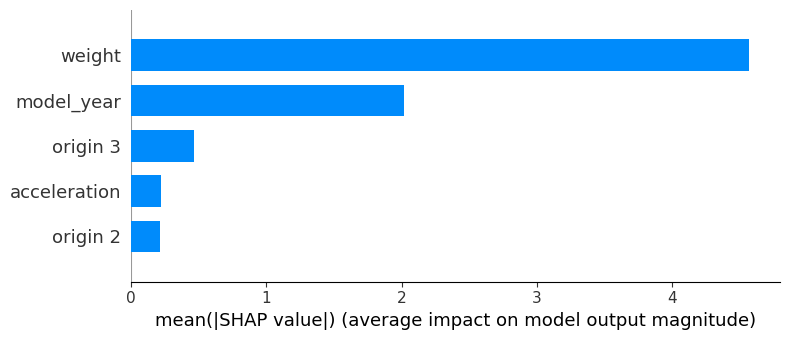

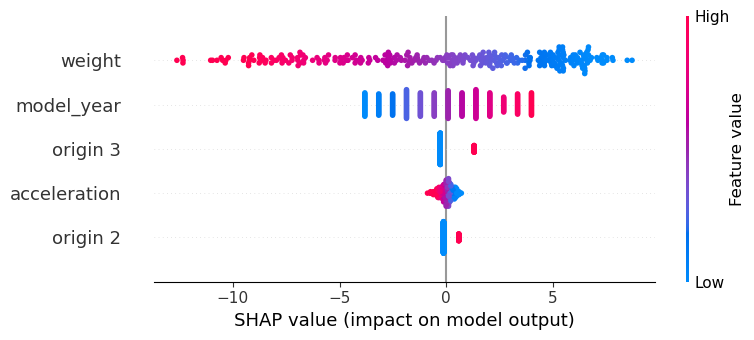

In [90]:
regressor.fit(X1_train, y1_train) #note to myself: I need to fit the model before applying shap method

masker = shap.maskers.Independent(X1_train, max_samples=297)
explainer = shap.LinearExplainer(regressor, masker)
shap_values = explainer(X1_train)

features = ['origin 2', 'origin 3', 'weight', 'acceleration', 'model_year']

shap.summary_plot(shap_values, X1_train, plot_type='bar', feature_names=features)
shap.summary_plot(shap_values, X1_train, feature_names=features)

### Feature Selection
##### As we can observe, and model_year have way higher shap values than the other features, which isn't surprise based on our previous correlation analysis at the top of this section. What this means is that these 2 features contribution for the prediction is higher, so I'm gonna keep these and drop the remaining one, and do a second cross-validation and access the measures. 

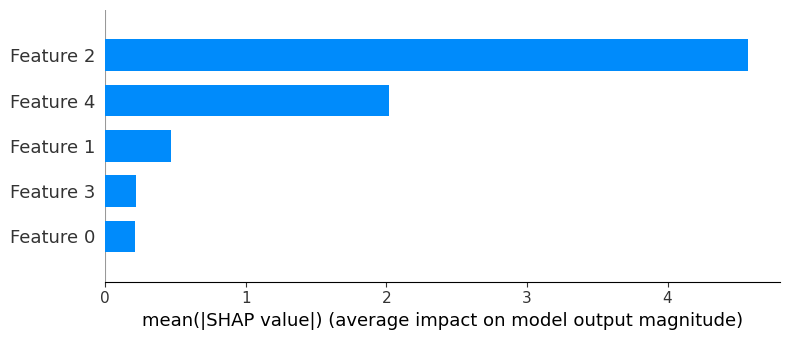

In [91]:
# to know the feature position
shap.summary_plot(shap_values, X1_train, plot_type='bar')

In [257]:
X1_train_first_drop = X1_train[:, [2, 4]]

In [258]:
X1_train_first_drop

array([[2226.,   72.],
       [3282.,   71.],
       [3139.,   71.],
       [2135.,   78.],
       [1955.,   71.],
       [2220.,   76.],
       [2070.,   78.],
       [2648.,   70.],
       [1825.,   76.],
       [2678.,   80.],
       [3900.,   79.],
       [1963.,   74.],
       [4054.,   79.],
       [4464.,   71.],
       [2472.,   73.],
       [2815.,   77.],
       [4657.,   75.],
       [2694.,   75.],
       [3160.,   81.],
       [2210.,   81.],
       [3755.,   76.],
       [3955.,   79.],
       [2957.,   75.],
       [2672.,   70.],
       [2123.,   71.],
       [2108.,   74.],
       [4335.,   77.],
       [2126.,   72.],
       [2542.,   74.],
       [2188.,   80.],
       [2984.,   75.],
       [3381.,   80.],
       [2720.,   77.],
       [3449.,   70.],
       [3121.,   73.],
       [2202.,   76.],
       [4096.,   71.],
       [1965.,   82.],
       [4165.,   77.],
       [2215.,   81.],
       [2464.,   76.],
       [4668.,   75.],
       [3821.,   73.],
       [280

In [259]:
X1_test_lr = np.delete(X1_test_lr, [0, 1, 3], axis = 1)

In [260]:
X1_test_lr

array([[3190.,   79.],
       [4654.,   73.],
       [2490.,   81.],
       [2401.,   73.],
       [2434.,   80.],
       [4325.,   77.],
       [3245.,   79.],
       [3840.,   79.],
       [2190.,   77.],
       [2228.,   71.],
       [2255.,   76.],
       [2075.,   77.],
       [2565.,   76.],
       [3535.,   78.],
       [2634.,   71.],
       [2385.,   81.],
       [3399.,   73.],
       [4735.,   73.],
       [3155.,   78.],
       [3140.,   78.],
       [3613.,   74.],
       [3230.,   81.],
       [2230.,   78.],
       [1975.,   81.],
       [2420.,   80.],
       [2003.,   74.],
       [1985.,   77.],
       [2660.,   73.],
       [2720.,   78.],
       [2592.,   75.],
       [2245.,   82.],
       [2945.,   73.],
       [3651.,   76.],
       [3907.,   75.],
       [2300.,   78.],
       [2904.,   73.],
       [2100.,   72.],
       [2835.,   82.],
       [3605.,   79.],
       [4135.,   72.],
       [2125.,   82.],
       [2205.,   82.],
       [4363.,   73.],
       [271

### Feature Selection Performance Assessment

In [95]:
print(f"Before feature drop measures:")
print(f"First R² (pooled predictions): {predict_loo_r2:.4f}")
print(f"First MAE: {predict_loo_mae:.2f}")
print(f"First overall RMSE: {predict_loo_rmse:.2f}")

regressor = LinearRegression()

loo = LeaveOneOut()

y1_predict_loo_first_drop = cross_val_predict(regressor, X1_train_first_drop, y1_train, cv=loo) #note to myself: change the X1_train

r2_first_drop = r2_score(y1_train, y1_predict_loo_first_drop)
mae_first_drop = mean_absolute_error(y1_train, y1_predict_loo_first_drop)
rmse_first_drop = np.sqrt(np.mean(np.square(y1_train - y1_predict_loo_first_drop)))

print(f"\nAfter features drop measures:")
print(f"LOOCV overall R²: {r2_first_drop:.4f}")
print(f"LOOCV overall MAE: {mae_first_drop:.2f}")
print(f"LOOCV overall RMSE: {rmse_first_drop:.2f}")

Before feature drop measures:
First R² (pooled predictions): 0.8468
First MAE: 2.24
First overall RMSE: 2.83

After features drop measures:
LOOCV overall R²: 0.8442
LOOCV overall MAE: 2.28
LOOCV overall RMSE: 2.85


##### Very interestingly, r squared didn't change almost, not even the other measures, even though there's been a little downgrade in all measures. I notice that the MAE dropped more than the RMSE, which is good, because even though we're getting less accurate predictions, is likely that these predictions aren't to far from the true value.

##### Let's calculate adjusted r squared for each situation

In [96]:
# let's build a function for adjusted r squared
def adjusted_r2(y_real, y_pred, n_features):
    n = len(y_real)
    r2 = r2_score(y_real, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

In [97]:
before_drop_r2 = adjusted_r2(y_real= y1_train, y_pred=y1_predict_loo, n_features=5)
after_drop_r2 = adjusted_r2(y_real= y1_train, y_pred=y1_predict_loo_first_drop, n_features=2)

print(f"Before features drop adjusted r2: {before_drop_r2:.4f}")
print(f"After features drop adjusted r2: {after_drop_r2:.4f}")

Before features drop adjusted r2: 0.8442
After features drop adjusted r2: 0.8431


##### As I was already expecting, because the difference in the features is only 3 and the r2 is very close to each other, it doesn't represent almost no difference for the adjusted r squared measure

### Fitting the model in the train data

In [146]:
regressor_lr = LinearRegression()
regressor_lr.fit(X1_train_first_drop, y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.01, 0.64]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.701
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[14681.78, 59.99]"


### Model Interpretation 

In [147]:
regressor_lr.coef_

array([-0.0065798 ,  0.63667902])

In [102]:
r2_lr = r2_first_drop 
mae_lr = mae_first_drop
rmse_lr = rmse_first_drop  

print(f"Linear Regression Model R²: {r2_lr:.2f}")
print(f"Linear Regression Model MAE: {mae_lr:.2f}")
print(f"Linear Regression Model RMSE: {rmse_lr:.2f}")

Linear Regression Model R²: 0.84
Linear Regression Model MAE: 2.28
Linear Regression Model RMSE: 2.85


#### The insights that we can take from the multiple linear regression model are:
- **Predictive Performance**: The model performs well on unseen observations (based on the LOOCV): r squared of 0.84, and an average error of 2.28 on full efficiency. This means that on average, for each MPG prediction on unseen data, if the prediction is 35, the value in reality can range between 32.72 mpg (38-2.28) and 37.28 mpg (35+2.28)
- **Number of features**: We still got a very similar performance with just 2 features compared to 5 (the initial training data)
- **Interpretability**: Based on this model we understand that the car's weight impacts in a negative way the fuel efficiency (it does make sense), but as higher the car's year is, better the efficiency (which alos makes sense in a general way). We can also take future actions insights: if we want to increase a car mpg by 1 unit, we should look for a way to decrease it's weight by 300kg. Or that if the company wants to sell efficient cars, it should look to buy newer and lighter cars.

## Regression Decision Tree Model

On this regression model, I'm gonna build 2 separate models - one with the original and another with the transformed dataset 

In [105]:
data_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
61,4,122.0,86.0,2226.0,16.5,72,1,21.0
47,6,250.0,100.0,3282.0,15.0,71,1,19.0
48,6,250.0,88.0,3139.0,14.5,71,1,18.0
279,4,98.0,68.0,2135.0,16.6,78,3,29.5
56,4,91.0,70.0,1955.0,20.5,71,1,26.0
...,...,...,...,...,...,...,...,...
237,4,98.0,63.0,2051.0,17.0,77,1,30.5
353,4,105.0,74.0,2190.0,14.2,81,2,33.0
220,4,85.0,70.0,1945.0,16.8,77,3,33.5
150,4,108.0,93.0,2391.0,15.5,74,3,26.0


In [104]:
data_test

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
299,4,141.0,71.0,3190.0,24.8,79,2,27.2
105,8,360.0,170.0,4654.0,13.0,73,1,13.0
338,4,135.0,84.0,2490.0,15.7,81,1,27.2
109,4,140.0,72.0,2401.0,19.5,73,1,21.0
320,4,119.0,92.0,2434.0,15.0,80,3,37.0
...,...,...,...,...,...,...,...,...
274,5,131.0,103.0,2830.0,15.9,78,2,20.3
65,8,351.0,153.0,4129.0,13.0,72,1,14.0
192,6,250.0,105.0,3353.0,14.5,76,1,22.0
153,6,250.0,105.0,3459.0,16.0,75,1,18.0


### Separate Features and Target

In [106]:
# original dataset
x1_train = data_train.iloc[:, :-1].values
y1_train = data_train.iloc[:, -1].values

x1_test = data_test.iloc[: , :-1].values
y1_test = data_test.iloc[:, -1].values

In [107]:
print(f"original training data separation:")
print(f"data_train shape: {data_train.shape}")
print(f"x1_train shape: {x1_train.shape}")
print(f"y1_train shape: {y1_train.shape}")

print(f"\noriginal test data separation:")
print(f"data_test shape: {data_test.shape}")
print(f"x1_test shape: {x1_test.shape}")
print(f"y1_test shape: {y1_test.shape}")


original training data separation:
data_train shape: (297, 8)
x1_train shape: (297, 7)
y1_train shape: (297,)

original test data separation:
data_test shape: (75, 8)
x1_test shape: (75, 7)
y1_test shape: (75,)


In [108]:
# transformed dataset
x2_train = data_transf_train.iloc[:, :-1].values
y2_train = data_transf_train.iloc[:, -1].values

x2_test = data_transf_test.iloc[: , :-1].values
y2_test = data_transf_test.iloc[:, -1].values

In [109]:
print(f"transformed training data separation:")
print(f"data_transf_train shape: {data_transf_train.shape}")
print(f"x2_train shape: {x2_train.shape}")
print(f"y2_train shape: {y2_train.shape}")

print(f"\ntransformed test data separation:")
print(f"data_transf_test shape: {data_transf_test.shape}")
print(f"x2_test shape: {x2_test.shape}")
print(f"y2_test shape: {y2_test.shape}")

transformed training data separation:
data_transf_train shape: (296, 8)
x2_train shape: (296, 7)
y2_train shape: (296,)

transformed test data separation:
data_transf_test shape: (75, 8)
x2_test shape: (75, 7)
y2_test shape: (75,)


### Categorical Variable Encoding

In [110]:
# original dataset
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [-1])], remainder='passthrough')
X1_train = np.array(ct.fit_transform(x1_train))
X1_test = np.array(ct.fit_transform(x1_test)) 

In [111]:
print(f"x1_train shape:{x1_train.shape}")
print(f"X1_train shape:{X1_train.shape}")
print(f"x1_test shape:{x1_test.shape}")
print(f"X1_test shape:{X1_test.shape}")

x1_train shape:(297, 7)
X1_train shape:(297, 8)
x1_test shape:(75, 7)
X1_test shape:(75, 8)


In [112]:
# transformed dataset
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [-1])], remainder='passthrough')
X2_train = np.array(ct.fit_transform(x2_train))
X2_test = np.array(ct.fit_transform(x2_test))

In [113]:
print(f"x2_train shape:{x2_train.shape}")
print(f"X2_train shape:{X2_train.shape}")
print(f"x2_test shape:{x2_test.shape}")
print(f"X2_test shape:{X2_test.shape}")

x2_train shape:(296, 7)
X2_train shape:(296, 8)
x2_test shape:(75, 7)
X2_test shape:(75, 8)


### Original dataset only
### Cross-Validation - LOOCV (Leave One Out Cross-Validation)

In [114]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=789)
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()

y1_predict_loo = cross_val_predict(regressor, X1_train, y1_train, cv=loo)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

predict_loo_r2 = r2_score(y1_train, y1_predict_loo)
predict_loo_mae = mean_absolute_error(y1_train, y1_predict_loo)
predict_loo_rmse = np.sqrt(np.mean(np.square(y1_train - y1_predict_loo)))

print(f"LOOCV overall R²: {predict_loo_r2:.4f}")
print(f"LOOCV overall MAE: {predict_loo_mae:.2f}")
print(f"LOOCV overall RMSE: {predict_loo_rmse:.2f}")

LOOCV overall R²: 0.8564
LOOCV overall MAE: 2.08
LOOCV overall RMSE: 2.74


#### Feature Selection

Again, I'm using SHAP method on my decision tree model to help me with feature selection. There's an **important note**: on our linear regression model I had to drop correlated features to avoid multicollinearity and lack of interpretability, but on our decision tree, we won't need do to that, I'll give more value for how much a feature matters to the predictions instead

In [115]:
import shap

##### Checking the features names

In [116]:
data_train.columns

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'mpg'],
      dtype='str')

In [117]:
feature_names = ct.get_feature_names_out()

print(feature_names)

['encoder__x6_2.0' 'encoder__x6_3.0' 'remainder__x0' 'remainder__x1'
 'remainder__x2' 'remainder__x3' 'remainder__x4' 'remainder__x5']


In [118]:
data_train.columns[0:-2]

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year'],
      dtype='str')

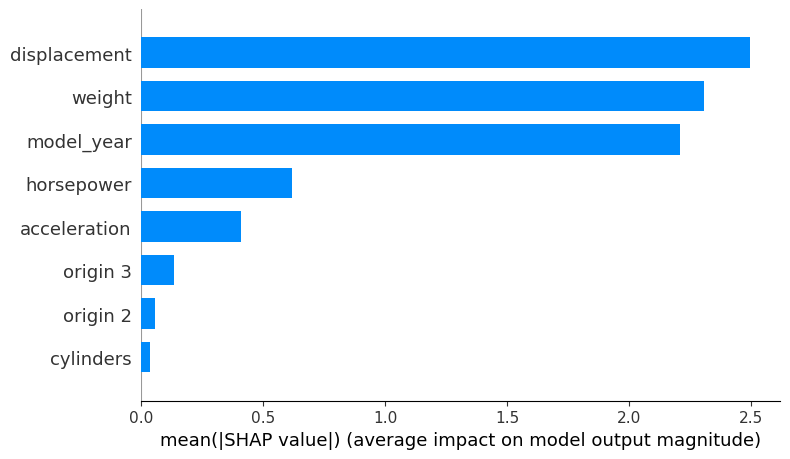

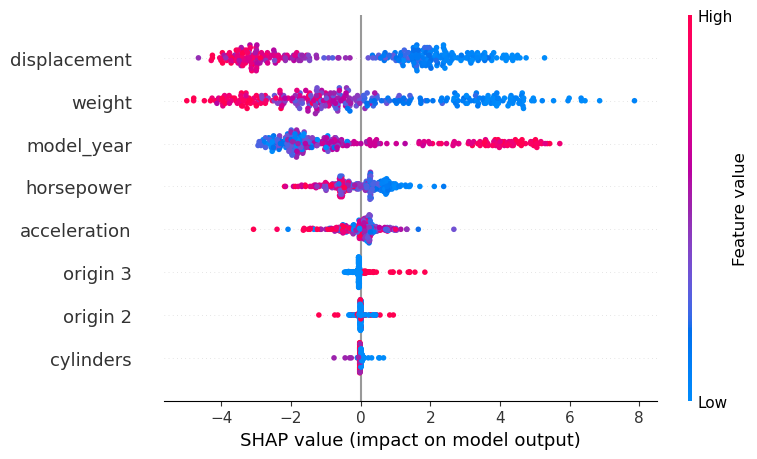

In [119]:
regressor.fit(X1_train, y1_train) 

masker = shap.maskers.Independent(X1_train, max_samples=297)
explainer = shap.TreeExplainer(regressor, masker)
shap_values = explainer(X1_train)

features = ['origin 2', 'origin 3', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

shap.summary_plot(shap_values, X1_train, plot_type='bar', feature_names=features)
shap.summary_plot(shap_values, X1_train, feature_names= features)

Surprisignly, displacement gets way higher target prediction contribution compared with horsepower and cylinders. This is interesting because in the EDA step we checked that these 3 had a very similar correlation with the target and also between each other. 
Nervteheless I'm gonna keep the 3 top features: displacement, weight and model_year

Just for the sake of curiosity, let me chek the tree plot to have a visual on the splits 

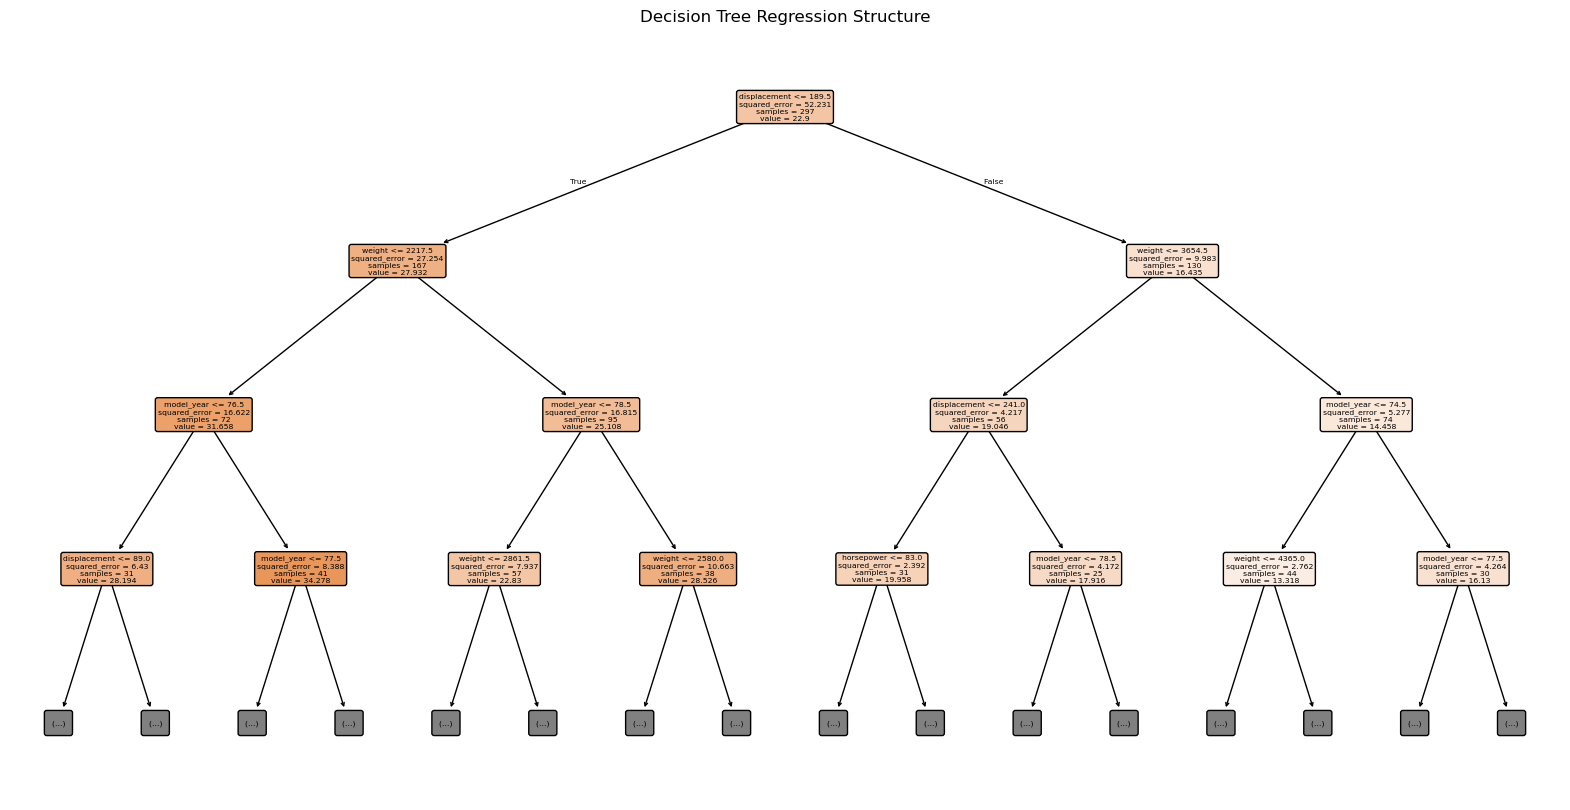

In [120]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

plt.figure(figsize=(20, 10))
plot_tree(regressor, filled=True, max_depth=3 ,feature_names=['origin 2', 'origin 3', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year'], rounded=True)
plt.title("Decision Tree Regression Structure")
plt.show()

Indeed the top 3 features are the ones in the first 3 split layers

### Features Drop

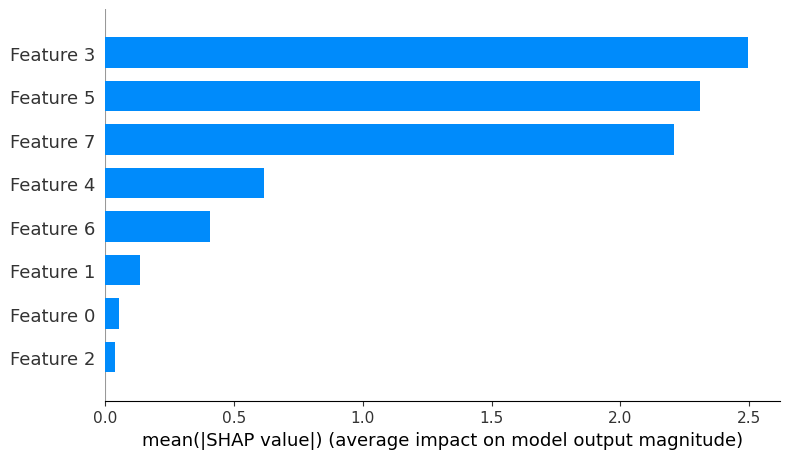

In [121]:
shap.summary_plot(shap_values, X1_train, plot_type='bar')

In [122]:
# keep the feature number 3, 5 and 7

X1_train_feat_sel = X1_train[:, [3, 5, 7]]
X1_train_feat_sel

array([[ 122. , 2226. ,   72. ],
       [ 250. , 3282. ,   71. ],
       [ 250. , 3139. ,   71. ],
       [  98. , 2135. ,   78. ],
       [  91. , 1955. ,   71. ],
       [ 116. , 2220. ,   76. ],
       [  85. , 2070. ,   78. ],
       [ 199. , 2648. ,   70. ],
       [  97. , 1825. ,   76. ],
       [ 151. , 2678. ,   80. ],
       [ 350. , 3900. ,   79. ],
       [  79. , 1963. ,   74. ],
       [ 351. , 4054. ,   79. ],
       [ 400. , 4464. ,   71. ],
       [ 155. , 2472. ,   73. ],
       [ 146. , 2815. ,   77. ],
       [ 351. , 4657. ,   75. ],
       [ 115. , 2694. ,   75. ],
       [ 145. , 3160. ,   81. ],
       [ 107. , 2210. ,   81. ],
       [ 318. , 3755. ,   76. ],
       [ 351. , 3955. ,   79. ],
       [ 120. , 2957. ,   75. ],
       [ 110. , 2672. ,   70. ],
       [ 116. , 2123. ,   71. ],
       [  90. , 2108. ,   74. ],
       [ 351. , 4335. ,   77. ],
       [  97.5, 2126. ,   72. ],
       [ 140. , 2542. ,   74. ],
       [  97. , 2188. ,   80. ],
       [ 1

In [123]:
X1_test_feat_sel = X1_test[:, [3, 5, 7]]

In [124]:
print(f"Before feature drop measures:")
print(f"First R²: {predict_loo_r2:.4f}")
print(f"First MAE: {predict_loo_mae:.2f}")
print(f"First overall RMSE: {predict_loo_rmse:.2f}")

regressor = DecisionTreeRegressor(random_state=789)

loo = LeaveOneOut()

y1_predict_feat_sel = cross_val_predict(regressor, X1_train_feat_sel, y1_train, cv=loo)

r2_feat_sel= r2_score(y1_train, y1_predict_feat_sel)
mae_feat_sel = mean_absolute_error(y1_train, y1_predict_feat_sel)
rmse_feat_sel = np.sqrt(np.mean(np.square(y1_train - y1_predict_feat_sel)))

print(f"\nAfter features drop:")
print(f"LOOCV overall R²: {r2_feat_sel:.4f}")
print(f"LOOCV overall MAE: {mae_feat_sel:.2f}")
print(f"LOOCV overall RMSE: {rmse_feat_sel:.2f}")

Before feature drop measures:
First R²: 0.8564
First MAE: 2.08
First overall RMSE: 2.74

After features drop:
LOOCV overall R²: 0.8470
LOOCV overall MAE: 2.14
LOOCV overall RMSE: 2.83


##### With the feature drop we had a very little decrease in our model performance. I prefer a model with less features and almost the same (good) accuracy, so the last one one is my choice for the decision tree regression model, on **original dataset**. Now I'll repeat the process for the logarithm transformed dataset (displacement and horsepower), check which one is performing better and then do some hyperparameter tunning.



### Transformed Dataset only

### LOOCV - Leave One Out Cross Validation

In [125]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=789)
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()

y2_first_cv = cross_val_predict(regressor, X2_train, y2_train, cv=loo)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

first_cv_r2 = r2_score(y2_train, y2_first_cv)
first_cv_mae = mean_absolute_error(y2_train, y2_first_cv)
firt_cv_rmse = np.sqrt(np.mean(np.square(y2_train - y2_first_cv)))

print(f"LOOCV overall R²: {first_cv_r2:.4f}")
print(f"LOOCV overall MAE: {first_cv_mae:.2f}")
print(f"LOOCV overall RMSE: {firt_cv_rmse:.2f}")

LOOCV overall R²: 0.8286
LOOCV overall MAE: 2.27
LOOCV overall RMSE: 2.99


Right here we can check a 0.82 r squared vs the 0.85 one. Let's dive a little more

### Feature Selection

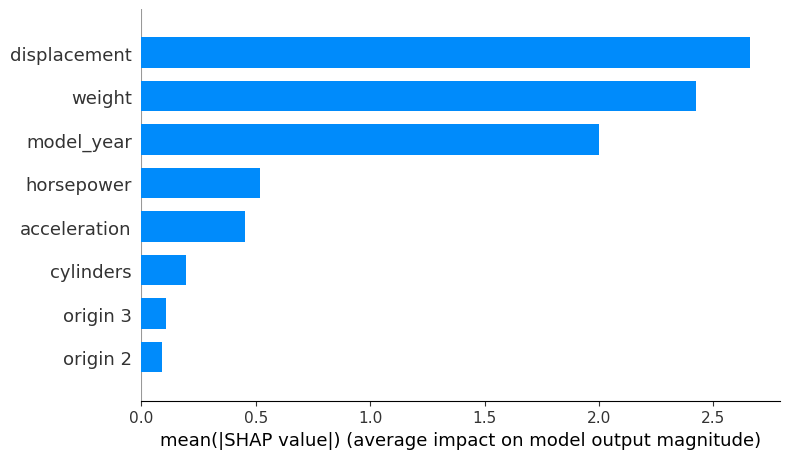

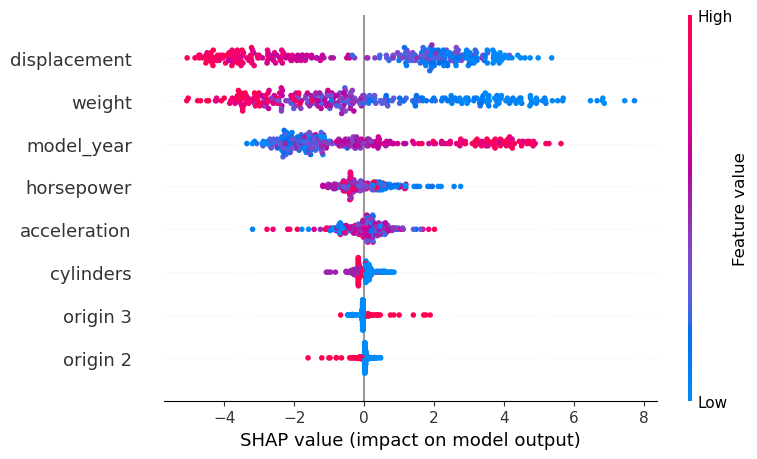

In [126]:
regressor.fit(X2_train, y2_train) 

masker = shap.maskers.Independent(X2_train, max_samples=296)
explainer = shap.TreeExplainer(regressor, masker)
shap_values = explainer(X2_train)

features = ['origin 2', 'origin 3', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

shap.summary_plot(shap_values, X2_train, plot_type='bar', feature_names=features)
shap.summary_plot(shap_values, X2_train, feature_names= features)

##### Compared with the original dataset, the feature mode_year has a slight lower importance, but nothing too representative. Just to give a more "experimental" touch, I'm gonna leave only the best 2 features to see how it performs. 

### Features Drop

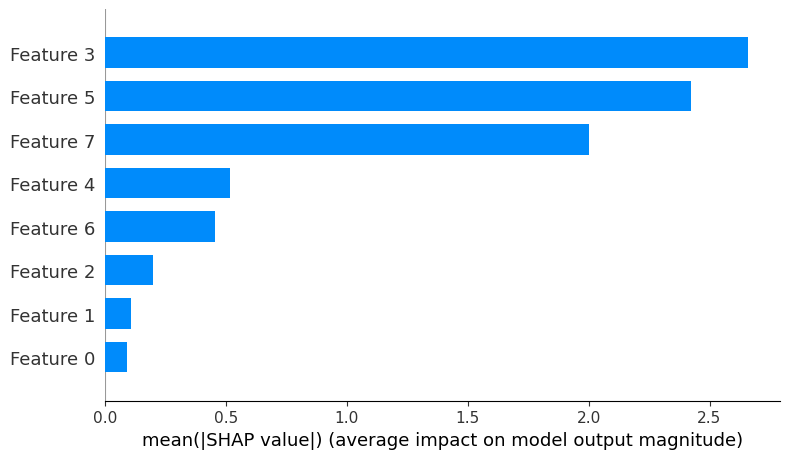

In [127]:
shap.summary_plot(shap_values, X2_train, plot_type='bar')

In [128]:
X2_train_feat_sel = X2_train[:, [3, 5]]

In [129]:
X2_test_feat_sel = X2_test[:, [3, 5]]

In [ ]:
print(f"Before features drop measures:")
print(f"First R²: {first_cv_r2:.4f}")
print(f"LOOCV overall MAE: {first_cv_mae:.2f}")
print(f"LOOCV overall RMSE: {firt_cv_rmse:.2f}")

regressor = DecisionTreeRegressor(random_state=789)

loo = LeaveOneOut()

y2_feat_sel = cross_val_predict(regressor, X2_train_feat_sel, y2_train, cv=loo)

second_cv_r2 = r2_score(y2_train, y2_feat_sel)
second_cv_mae = mean_absolute_error(y2_train, y2_feat_sel)
second_cv_rmse = np.sqrt(np.mean(np.square(y2_train - y2_feat_sel)))

print(f"\nAfter features drop measures:")
print(f"LOOCV overall R²: {second_cv_r2:.4f}")
print(f"LOOCV overall MAE: {second_cv_mae:.2f}")
print(f"LOOCV overall RMSE: {second_cv_rmse:.2f}")

Before features drop measures:
First R²: 0.8286
LOOCV overall MAE: 2.27
LOOCV overall RMSE: 2.99%

After features drop measures:
LOOCV overall R²: 0.8350
LOOCV overall MAE: 2.28
LOOCV overall RMSE: 2.94


##### Apparently there was a huge downgrade, probably because I dropped model_year, which is a feature with a considerable contribution for the prediction. Let's do a third cross-validation with the top 3 features

In [130]:
X2_train_feat_sel = X2_train[:, [3, 5, 7]]
X2_test_feat_sel = X2_test[:, [3, 5, 7]]

In [143]:
print(f"2 features measures:")
print(f"LOOCV overall R²: {second_cv_r2:.4f}")
print(f"LOOCV overall MAE: {second_cv_mae:.2f}")
print(f"LOOCV overall RMSE: {second_cv_rmse:.2f}")

regressor = DecisionTreeRegressor(random_state=789)

loo = LeaveOneOut()

y2_feat_sel = cross_val_predict(regressor, X2_train_feat_sel, y2_train, cv=loo)

third_cv_r2 = r2_score(y2_train, y2_feat_sel)
third_cv_mae = mean_absolute_error(y2_train, y2_feat_sel)
third_cv_rmse = np.sqrt(np.mean(np.square(y2_train - y2_feat_sel)))

print(f"\n3 features measures:")
print(f"LOOCV overall R²: {third_cv_r2:.4f}")
print(f"LOOCV overall MAE: {third_cv_mae:.2f}")
print(f"LOOCV overall RMSE: {third_cv_rmse:.2f}")

2 features measures:
LOOCV overall R²: 0.8350
LOOCV overall MAE: 2.28
LOOCV overall RMSE: 2.94

3 features measures:
LOOCV overall R²: 0.8350
LOOCV overall MAE: 2.28
LOOCV overall RMSE: 2.94


##### We're back in the 80's accuracy, but since the **original data** has a slight more accuracy, **we'll move ahead with that one**. 

### Hyperparameter Tunning - Original Dataset Only

As I said before, I've used the leave one out type of cross-validation because of our dataset size. Ideally we would join a cross-validation with a train-validation-test split to help our hyperparameter tunning by testing the hyperparameters combination on a whole unsee data, but that's not concievable because of our dataset size. Nevertheless I can still use cross-validation as a way to check how each hyperparameter choosen combination is performing. 
For the hyperparameter tunning I'm gonna use a **Grid Search** method, for the same reasons I used a leave one out cross validation - small datasize, no computational costs problems

In [ ]:
?DecisionTreeRegressor

Init signature:
DecisionTreeRegressor(
    *,
    criterion='squared_error',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree regressor.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"squared_error", "absolute_error", "poisson"}, default="squared_error"
    The function to measure the quality of a split. Supported criteria
    are "squared_error" for the mean squared error, which is equal to
    variance reduction as feature selection criterion and minimizes the L2
    loss using the mean of each terminal node, "absolute_error" for the mean
    absolute error, which minimizes the L1 loss using the median of each terminal
    node, and "poisson" which uses reduction in Poisson deviance to find splits,
  

In [136]:
from sklearn.model_selection import GridSearchCV

regressor = DecisionTreeRegressor(random_state=789)
parameters = [{'max_depth': [5, 7, 9], 'min_samples_split': [10, 20, 50], 'min_samples_leaf': [20, 25]}]

grid_search = GridSearchCV(estimator= regressor, param_grid= parameters, scoring= 'neg_mean_absolute_error', cv= LeaveOneOut())
grid_search.fit(X1_train_feat_sel, y1_train)

best_mae = - grid_search.best_score_
best_parameters = grid_search.best_params_

In [137]:
print(f"Best MAE: {best_mae:.4f}")
print(f"Best parameters: {best_parameters}")

Best MAE: 2.1203
Best parameters: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10}


#### Analyzing the performance between untunned and tunned model on **training data**, and remember, **we're using original dataset**
In order to do this, I need to use cross-validation, otherwise I can't get the r squared, since in the GridSeacrch step, the prediction vs true value calculations are made per fold, so it's mathematically impossible to claculate r squared with a single value. 

In this cross validation **I'll use the regressor with the tunned parameters**, that's the whole point of it 

In [145]:
print(f"Untuned model:")
print(f"LOOCV overall R²: {r2_feat_sel:.4f}")
print(f"LOOCV overall MAE: {mae_feat_sel:.2f}")
print(f"LOOCV overall RMSE: {rmse_feat_sel:.2f}")

regressor = grid_search.best_estimator_

loo = LeaveOneOut()

y_final_cv = cross_val_predict(regressor, X1_train_feat_sel, y1_train, cv=loo)

r2_dt = r2_score(y1_train, y_final_cv)
mae_dt = mean_absolute_error(y1_train, y_final_cv)
rmse_dt = np.sqrt(np.mean(np.square(y1_train - y_final_cv)))

print(f"\nTuned model:")
print(f"Decision Tree Model R²: {r2_dt:.2f}")
print(f"Decision Tree Model MAE: {mae_dt:.2f}")
print(f"Decision Tree Model RMSE: {rmse_dt:.2f}")

Untuned model:
LOOCV overall R²: 0.8470
LOOCV overall MAE: 2.14
LOOCV overall RMSE: 2.83

Tuned model:
Decision Tree Model R²: 0.86
Decision Tree Model MAE: 2.12
Decision Tree Model RMSE: 2.73


##### There's been a considerable improvement on all 3 measures, specially on the rmse measure. This tells us that the model has on average, a lower absolute error but also the penalties for bigger errors is also lower. This means that the errors are getting in average closer to the prediction, in other words, we're making less too far from the real value predictions. This is our final decision tree model

### Fitting the model in the train data

### The GridSearchCV already fitted the model, the last step after defining the winning hyperparameters combination with the LOOCV is to do a fit using all the train data. 

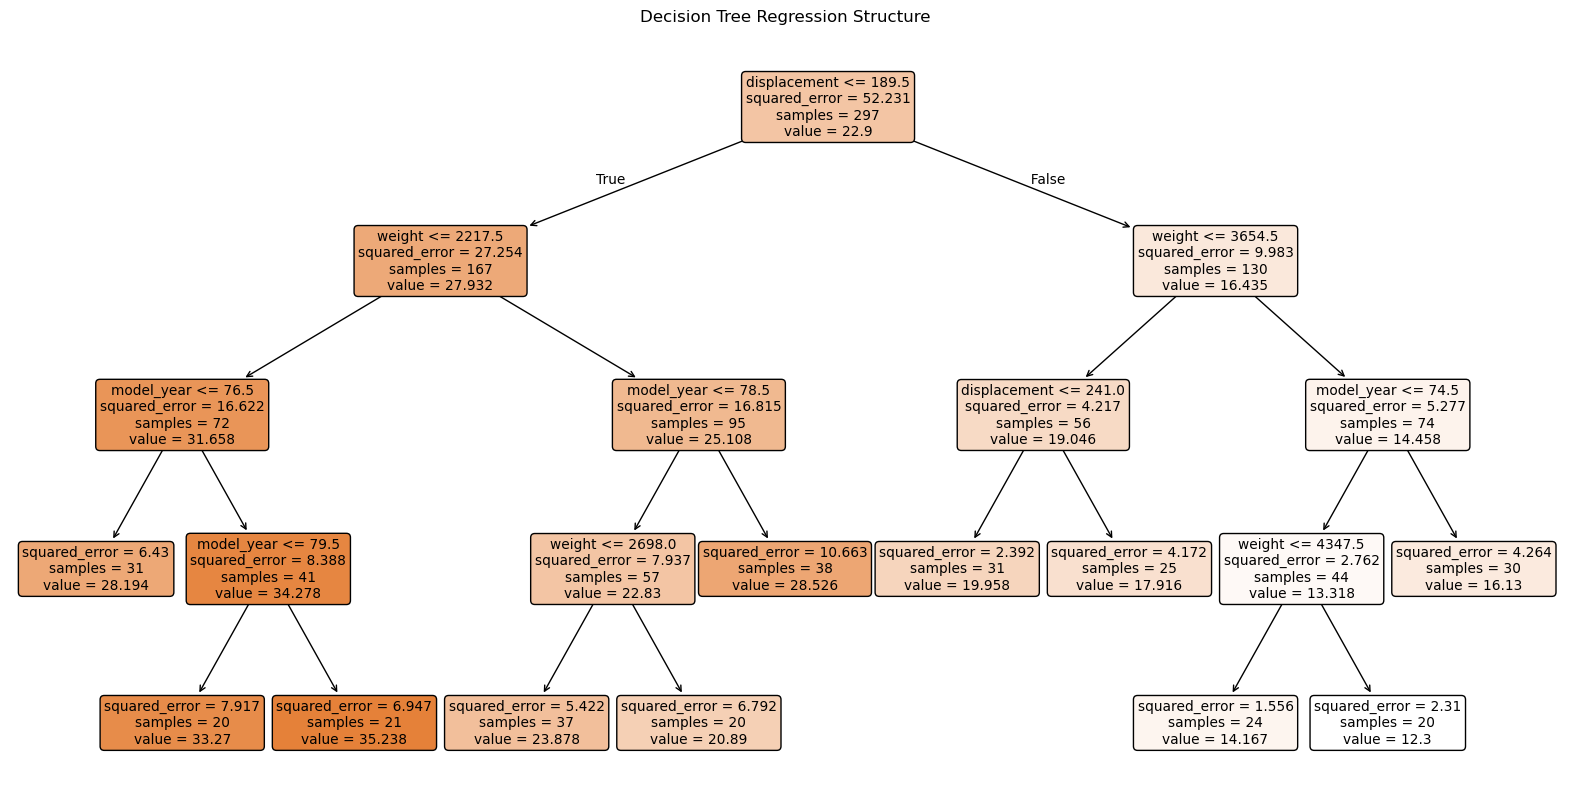

In [ ]:
regressor_dt = grid_search.best_estimator_

plt.figure(figsize=(20, 10))
plot_tree(regressor_dt, filled=True, feature_names=["displacement", "weight", "model_year"], rounded=True)
plt.title("Decision Tree Regression Structure")
plt.show()

In [ ]:
# checking the winning parameters
grid_search.best_params_

{'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10}

### Model Interpretation:
- **Predictive performance**: the model can explain 0.86 of the variance in the MPG variable, which shows good predictive capacity
- **Number of Features**: again, we checked that using 3 features or all features doesn't change too much the predictive capacity of the model, so I prefer using just 3 and haver a better interpretability capacity 
- **Interpretability**: the decision tree model also gives us a good interpretability like the linear regression. Using the ploteed tree we can, for example understand that cars with a displacement below 189.5cc have a higher fuel efficiency than the ones above it. And that if it has a weigt below 2217.5 kg and model_year above 79.5, these are the best efficient cars. On the other side, the heavier, higher displacement and older cars are the least efficient ones. The tree just confirms what our insights from the EDA step - displacement and weight have a negative correlation with fuel efficiency, and model year as a positive one. 
- **Complexity**: The decision tree gives us a higher interpretability capacity compared with the linear regression, because we can better undertand based on 3 features, in wich 11 boxes (the tree leafs) of fuel efficiency a car will be, based on these 3 features dinamics. It's a more dynamic model, not so straightforward like the linear regression.

## Regression Random Forest Model

### 2 Notes:
- Since we already check that the transformed dataset doesnt bring any representative value to our model development, I'm gonna strict the random forest model to the original dataset
- Since I'm gonna use the same data as the linear regression model, I'll pick the data post features drop and just basically do the same thing to prepare the data to train


In [162]:
data_train_rf = data_train_lr
data_test_rf= data_test_lr 

### Separate the features from the target

#### Train Dataset

In [168]:
x1_train_rf = data_train_rf.iloc[:, :-1].values
y1_train_rf = data_train_rf.iloc[:, -1].values

In [169]:
x1_train_rf

array([[2.226e+03, 1.650e+01, 7.200e+01, 1.000e+00],
       [3.282e+03, 1.500e+01, 7.100e+01, 1.000e+00],
       [3.139e+03, 1.450e+01, 7.100e+01, 1.000e+00],
       ...,
       [1.945e+03, 1.680e+01, 7.700e+01, 3.000e+00],
       [2.391e+03, 1.550e+01, 7.400e+01, 3.000e+00],
       [1.834e+03, 1.900e+01, 7.100e+01, 2.000e+00]], shape=(297, 4))

#### Test Dataset

In [170]:
x1_test_rf = data_test_rf.iloc[:, :-1].values
y1_test_rf = data_test_rf.iloc[:, -1].values

In [171]:
x1_test_rf

array([[3.190e+03, 2.480e+01, 7.900e+01, 2.000e+00],
       [4.654e+03, 1.300e+01, 7.300e+01, 1.000e+00],
       [2.490e+03, 1.570e+01, 8.100e+01, 1.000e+00],
       [2.401e+03, 1.950e+01, 7.300e+01, 1.000e+00],
       [2.434e+03, 1.500e+01, 8.000e+01, 3.000e+00],
       [4.325e+03, 1.220e+01, 7.700e+01, 1.000e+00],
       [3.245e+03, 1.540e+01, 7.900e+01, 1.000e+00],
       [3.840e+03, 1.540e+01, 7.900e+01, 1.000e+00],
       [2.190e+03, 1.410e+01, 7.700e+01, 2.000e+00],
       [2.228e+03, 1.400e+01, 7.100e+01, 3.000e+00],
       [2.255e+03, 1.770e+01, 7.600e+01, 1.000e+00],
       [2.075e+03, 1.590e+01, 7.700e+01, 1.000e+00],
       [2.565e+03, 1.360e+01, 7.600e+01, 1.000e+00],
       [3.535e+03, 1.920e+01, 7.800e+01, 1.000e+00],
       [2.634e+03, 1.300e+01, 7.100e+01, 1.000e+00],
       [2.385e+03, 1.290e+01, 8.100e+01, 1.000e+00],
       [3.399e+03, 1.100e+01, 7.300e+01, 1.000e+00],
       [4.735e+03, 1.100e+01, 7.300e+01, 1.000e+00],
       [3.155e+03, 1.820e+01, 7.800e+01, 1.000

##### Making sure separation was done well

In [172]:
print(f"original training data separation:")
print(f"data_train shape: {data_train_rf.shape}")
print(f"x1_train shape: {x1_train_rf.shape}")
print(f"y1_train shape: {y1_train_rf.shape}")

print(f"\noriginal test data separation:")
print(f"data_test shape: {data_test_rf.shape}")
print(f"x1_test shape: {x1_test_rf.shape}")
print(f"y1_test shape: {y1_test_rf.shape}")

original training data separation:
data_train shape: (297, 5)
x1_train shape: (297, 4)
y1_train shape: (297,)

original test data separation:
data_test shape: (75, 5)
x1_test shape: (75, 4)
y1_test shape: (75,)


### Categorical Variable Encoding

In [173]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct_rf = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [-1])], remainder='passthrough')
X1_train_rf = np.array(ct_rf.fit_transform(x1_train_rf))
X1_test_rf = np.array(ct_rf.fit_transform(x1_test_rf))

In [174]:
X1_train_rf

array([[0.000e+00, 0.000e+00, 2.226e+03, 1.650e+01, 7.200e+01],
       [0.000e+00, 0.000e+00, 3.282e+03, 1.500e+01, 7.100e+01],
       [0.000e+00, 0.000e+00, 3.139e+03, 1.450e+01, 7.100e+01],
       ...,
       [0.000e+00, 1.000e+00, 1.945e+03, 1.680e+01, 7.700e+01],
       [0.000e+00, 1.000e+00, 2.391e+03, 1.550e+01, 7.400e+01],
       [1.000e+00, 0.000e+00, 1.834e+03, 1.900e+01, 7.100e+01]],
      shape=(297, 5))

#### Making sure the encoding was done well

In [176]:
print(f"x1 train shape:{X1_train_rf.shape}")
print(f"x1 test shape:{X1_test_rf.shape}")

x1 train shape:(297, 5)
x1 test shape:(75, 5)


### Train a Random Forest Model - X1_train_rf dataset

### Leave One Out Cross Validation
### Some important considerations: 
- I'm gonna set up my random forest with some default hyperparameters
- I'm aware that a leave one out cross validaton in a random forest can escalate the computational cost very qucikly, because in our situation, each tree in the forest will do 297 fits, but since the dataset is small I won't need to manny trees, and I also want to keep some similarity between models to help me have a better comparison understanding, i.e., I don't want to change the cross validation variable between models 

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor_rf = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=789)
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()

y1_predict_loo_rf = cross_val_predict(regressor_rf, X1_train_rf, y1_train_rf, cv=loo)

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

predict_cv1_r2 = r2_score(y1_train_rf, y1_predict_loo_rf)
predict_cv1_mae = mean_absolute_error(y1_train_rf, y1_predict_loo_rf)
predict_cv1_rmse = root_mean_squared_error(y1_train_rf, y1_predict_loo_rf)

print(f"First LOOCV overall R²: {predict_cv1_r2:.4f}")
print(f"First LOOCV overall MAE: {predict_cv1_mae:.2f}")
print(f"First LOOCV overall RMSE: {predict_cv1_rmse:.2f}")

First LOOCV overall R²: 0.9020
First LOOCV overall MAE: 1.78
First LOOCV overall RMSE: 2.26


#### First Analysis: we can already notice that the first (before any feature selection ahd hyperparameter tunning) r square is at 0.9, which is the best score so far, even after some work on the other 2 models. We can start to notice the random forest power. 

### Feature Selection - SHAP method

In [179]:
import shap

#### Checking the features names

In [184]:
data_train_rf.columns

Index(['weight', 'acceleration', 'model_year', 'origin', 'mpg'], dtype='str')

In [182]:
feature_names = ct_rf.get_feature_names_out()

feature_names

array(['encoder__x3_2.0', 'encoder__x3_3.0', 'remainder__x0',
       'remainder__x1', 'remainder__x2'], dtype=object)

In [185]:
data_train_rf.columns[0:-2]

Index(['weight', 'acceleration', 'model_year'], dtype='str')

#### Shap Method

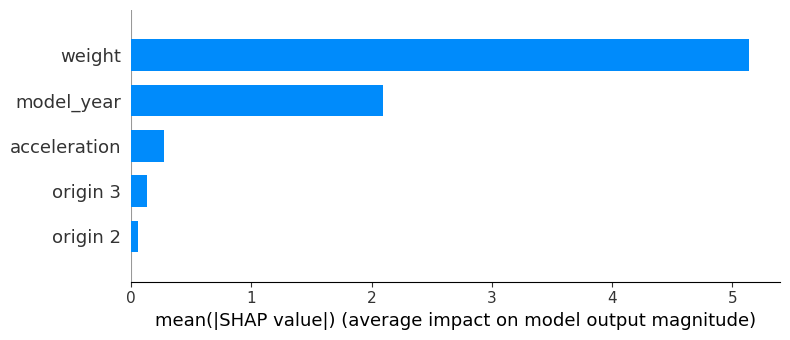

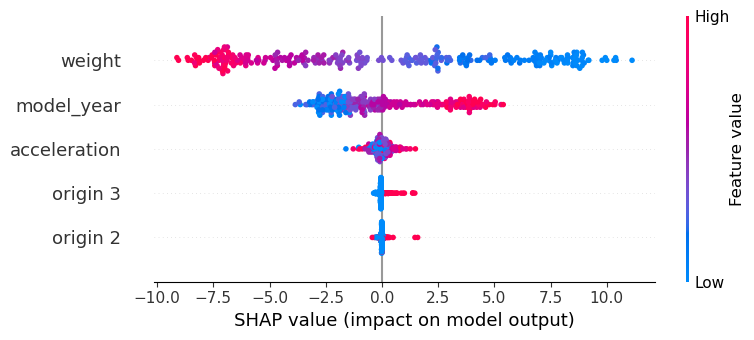

In [187]:
regressor_rf.fit(X1_train_rf, y1_train_rf) 

masker = shap.maskers.Independent(X1_train_rf, max_samples=297)
explainer = shap.TreeExplainer(regressor_rf, masker)
shap_values = explainer(X1_train_rf)

features = ['origin 2', 'origin 3', 'weight', 'acceleration', 'model_year']

shap.summary_plot(shap_values, X1_train_rf, plot_type='bar', feature_names=features)
shap.summary_plot(shap_values, X1_train_rf, feature_names= features)

##### Analysis: Any surprise here, I already expected that weight and model_year would dominate the feature contribution - since we don't have the displacement feature -, this has been a pattern. These are the 2 features to keep as I did with the linear regression.

#### Features Drop

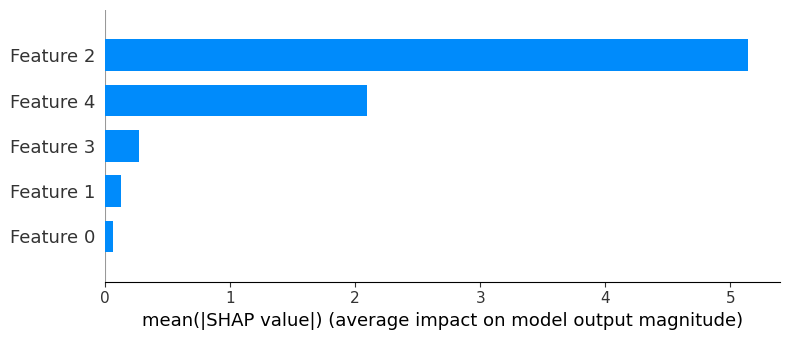

In [189]:
shap.summary_plot(shap_values, X1_train_rf, plot_type='bar')

##### Train Data

In [193]:
# keep the features number 2 and 4
X1_train_rf = np.delete(X1_train_rf, [0, 1, 3], axis=1)

In [195]:
# checking
X1_train_rf

array([[2226.,   72.],
       [3282.,   71.],
       [3139.,   71.],
       [2135.,   78.],
       [1955.,   71.],
       [2220.,   76.],
       [2070.,   78.],
       [2648.,   70.],
       [1825.,   76.],
       [2678.,   80.],
       [3900.,   79.],
       [1963.,   74.],
       [4054.,   79.],
       [4464.,   71.],
       [2472.,   73.],
       [2815.,   77.],
       [4657.,   75.],
       [2694.,   75.],
       [3160.,   81.],
       [2210.,   81.],
       [3755.,   76.],
       [3955.,   79.],
       [2957.,   75.],
       [2672.,   70.],
       [2123.,   71.],
       [2108.,   74.],
       [4335.,   77.],
       [2126.,   72.],
       [2542.,   74.],
       [2188.,   80.],
       [2984.,   75.],
       [3381.,   80.],
       [2720.,   77.],
       [3449.,   70.],
       [3121.,   73.],
       [2202.,   76.],
       [4096.,   71.],
       [1965.,   82.],
       [4165.,   77.],
       [2215.,   81.],
       [2464.,   76.],
       [4668.,   75.],
       [3821.,   73.],
       [280

##### Test Data

In [198]:
# drop features
X1_test_rf = np.delete(X1_test_rf, [0, 1, 3], axis=1)

IndexError: index 3 is out of bounds for axis 0 with size 2

In [199]:
# Checking
X1_test_rf

array([[3190.,   79.],
       [4654.,   73.],
       [2490.,   81.],
       [2401.,   73.],
       [2434.,   80.],
       [4325.,   77.],
       [3245.,   79.],
       [3840.,   79.],
       [2190.,   77.],
       [2228.,   71.],
       [2255.,   76.],
       [2075.,   77.],
       [2565.,   76.],
       [3535.,   78.],
       [2634.,   71.],
       [2385.,   81.],
       [3399.,   73.],
       [4735.,   73.],
       [3155.,   78.],
       [3140.,   78.],
       [3613.,   74.],
       [3230.,   81.],
       [2230.,   78.],
       [1975.,   81.],
       [2420.,   80.],
       [2003.,   74.],
       [1985.,   77.],
       [2660.,   73.],
       [2720.,   78.],
       [2592.,   75.],
       [2245.,   82.],
       [2945.,   73.],
       [3651.,   76.],
       [3907.,   75.],
       [2300.,   78.],
       [2904.,   73.],
       [2100.,   72.],
       [2835.,   82.],
       [3605.,   79.],
       [4135.,   72.],
       [2125.,   82.],
       [2205.,   82.],
       [4363.,   73.],
       [271

### Second Cross Validation (after feature selection)

In [201]:
print(f"Before feature drop measures:")
print(f"First R²: {predict_cv1_r2:.4f}")
print(f"First MAE: {predict_cv1_mae:.2f}")
print(f"First overall RMSE: {predict_cv1_rmse:.2f}")

regressor_rf = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=789)

loo = LeaveOneOut()

y1_predict_2_loo_rf = cross_val_predict(regressor_rf, X1_train_rf, y1_train_rf, cv=loo)

predict_cv2_r2= r2_score(y1_train_rf, y1_predict_2_loo_rf)
predict_cv2_mae = mean_absolute_error(y1_train_rf, y1_predict_2_loo_rf)
predict_cv2_rmse = root_mean_squared_error(y1_train_rf, y1_predict_2_loo_rf)

print(f"\nAfter features drop:")
print(f"Second R²: {predict_cv2_r2:.4f}")
print(f"Second MAE: {predict_cv2_mae:.2f}")
print(f"Second RMSE: {predict_cv2_rmse:.2f}")

Before feature drop measures:
First R²: 0.9020
First MAE: 1.78
First overall RMSE: 2.26

After features drop:
Second R²: 0.8767
Second MAE: 1.97
Second RMSE: 2.54


#### Analysis: Again, a constant pattern we've been seen is that after the features drop is also a slight drop in the performance measures: we're predicting with less accuracy and the model is capturing less the targte variation. But again, nothing representative, it's a good trade-off between model complexity and interpretability  

### Hyperparameter Tunning 

Repeat the hyperparameter tunning process as we did for the decision tree. 

#### Some considerations: 
- We have **different hyperparameters** to optimize in the random forest, but for our scenario, the main one will be the number of trees ('n_estimators' argument). The other hyperparameters I'll use the ones used in the decision tree
- I'll keep using the **GridSearch** with a **K-Fold cross validation** to help me manage the computational costs of this tunning, which will let me explore more number of hyperparameters combinations."

In [214]:
from sklearn.model_selection import GridSearchCV, KFold

regressor_rf = RandomForestRegressor(bootstrap=True, criterion='squared_error', random_state=789)
parameters = [{'n_estimators': [25, 50, 100, 200, 500, 1000], 'max_depth': [5, 7, 9], 'min_samples_split': [10, 20, 50], 'min_samples_leaf': [20, 25]}]

grid_search_rf = GridSearchCV(estimator = regressor_rf, param_grid= parameters, scoring= 'neg_mean_absolute_error', cv=KFold(n_splits=20, shuffle=True, random_state=789), n_jobs=-1, verbose=2)
grid_search_rf.fit(X1_train_rf, y1_train_rf)

best_mae = - grid_search_rf.best_score_
best_parameters = grid_search_rf.best_params_

Fitting 20 folds for each of 108 candidates, totalling 2160 fits


In [215]:
print(f"Best MAE: {best_mae:.2f}")
print(f"Best parameters: {best_parameters}")

Best MAE: 2.06
Best parameters: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10, 'n_estimators': 500}


### LOOCV with the tuned hyperparameters

Now I'll use again the leave one out cross validation

In [217]:
print(f"Untuned model:")
print(f"Second R²: {predict_cv2_r2:.2f}")
print(f"Second MAE: {predict_cv2_mae:.2f}")
print(f"Second RMSE: {predict_cv2_rmse:.2f}")

regressor_rf_ht = grid_search_rf.best_estimator_

loo = LeaveOneOut()

y_final_cv = cross_val_predict(regressor_rf_ht, X1_train_rf, y1_train_rf, cv=loo)

r2_rf_1t = r2_score(y1_train, y_final_cv)
mae_rf_1t = mean_absolute_error(y1_train, y_final_cv)
rmse_rf_1t = root_mean_squared_error(y1_train_rf, y_final_cv)

print(f"\nTuned model:")
print(f"First tuned R²: {r2_rf_1t:.2f}")
print(f"First tuned MAE: {mae_rf_1t:.2f}")
print(f"First tuned RMSE: {rmse_rf_1t:.2f}")

Untuned model:
Second R²: 0.88
Second MAE: 1.97
Second RMSE: 2.54

Tuned model:
First tuned R²: 0.87
First tuned MAE: 2.02
First tuned RMSE: 2.63


#### Analysis: honestly these results aren't what I expected. But it's ok, I can take information from this: the deafult parameters beat the tuned ones. There's an important point: the hyperparameter tunning was done with a k-fold cross validation, not a leave one out, even though I did a leave one out cross validation with the hyperparameters. Which leads me to think that maybe the problem is in the hyperparameters, because a 20 k-fold for a 297 rows dataset looks a very reasonable one, so I don't think the problem is on the cross validation used in the hyperparameters tunning. 

#### I'll do a second hyperparameter tunning, with a less restrictive values (closer to the default ones) 

### Second hyperparameter tunning 

In [218]:
regressor_rf = RandomForestRegressor(bootstrap=True, criterion='squared_error', random_state=789)
parameters = [{'n_estimators': [250, 500, 750], 'min_samples_split': [5, 8], 'min_samples_leaf': [3, 5]}]

grid_search_rf_2t = GridSearchCV(estimator = regressor_rf, param_grid= parameters, scoring= 'neg_mean_absolute_error', cv=KFold(n_splits=20, shuffle=True, random_state=789), n_jobs=-1, verbose=2)
grid_search_rf_2t.fit(X1_train_rf, y1_train_rf)

best_mae = - grid_search_rf_2t.best_score_
best_parameters = grid_search_rf_2t.best_params_

Fitting 20 folds for each of 12 candidates, totalling 240 fits


In [219]:
print(f"Best MAE: {best_mae:.2f}")
print(f"Best parameters: {best_parameters}")

Best MAE: 1.80
Best parameters: {'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 250}


##### Just for the MAE value we can check that there's been an improvement. Interesting, the optimal number of trees is 250 and not 500 as before. We got a higher MAE with less trees, which makes me more secure of the reasons for the "bad" performance of our first tuned model. The model neede more "freedom" and not necessarily more "training power" (number of trees).

### LOOCV with the second tuned hyperparameters

In [221]:
print(f"First tuned model:")
print(f"First tuned R²: {r2_rf_1t:.2f}")
print(f"First tuned MAE: {mae_rf_1t:.2f}")
print(f"First tuned RMSE: {rmse_rf_1t:.2f}")

regressor_rf_ht = grid_search_rf_2t.best_estimator_

loo = LeaveOneOut()

y_final_cv_2t = cross_val_predict(regressor_rf_ht, X1_train_rf, y1_train_rf, cv=loo)

r2_rf_2t = r2_score(y1_train, y_final_cv_2t)
mae_rf_2t = mean_absolute_error(y1_train, y_final_cv_2t)
rmse_rf_2t = root_mean_squared_error(y1_train_rf, y_final_cv_2t)

print(f"\nSecond Tuned model:")
print(f"Second tuned R²: {r2_rf_2t:.2f}")
print(f"Second tuned MAE: {mae_rf_2t:.2f}")
print(f"Second tuned RMSE: {rmse_rf_2t:.2f}")

First tuned model:
First tuned R²: 0.87
First tuned MAE: 2.02
First tuned RMSE: 2.63

Second Tuned model:
Second tuned R²: 0.89
Second tuned MAE: 1.82
Second tuned RMSE: 2.37


In [ ]:
print(f"Untuned model:")
print(f"Second R²: {predict_cv2_r2:.2f}")
print(f"Second MAE: {predict_cv2_mae:.2f}")
print(f"Second RMSE: {predict_cv2_rmse:.2f}")

Untuned model:
Second R²: 0.88
Second MAE: 1.97
Second RMSE: 2.54


In [223]:
r2_rf = r2_rf_2t
mae_rf = mae_rf_2t
rmse_rf = rmse_rf_2t

#### Analysis: after the second hyperparameter tunning we got better at all 3 performance measures, not only compared with the first tunned model, but also with the untuned one. So indeed, the model just needed deeper trees and less observations per split to imporve its predictive capacity.  

### Model Interpretation:
- **Predictive performance**: the model captured 0.88 of the variance in the MPG variable, as also just 1.97 mean absolute error, which shows good predictive capacity
- **Number of Features**: again, we checked that using 2 features or the 5 initial features doesn't change too much the predictive capacity of the model, so I prefer using just 2 and haver a better interpretability capacity 
- **Interpretability**: the random forest model interpretability is more limited compared with the previous 2. We can't exatly know the "path" that the model took like in a decision tree for example. Or say how much we need to reduce the car's weight, on average, to get an imporvement of 1 in the mpg as in the linear regression. But nevertheless, with the SHAP method we can see how each feature contributes for the prediction, so we can still have some interpretability. 
- **Complexity**: The random forest is a way more complex model, it's an **ensemble model made using bagging**, which means that we used an aggregation of multiple same models, ins this case, decision trees. Each decision tree was trained with a random sample of the whole data (**bootstrap sampling**), made a prediction (using a specific number of features randomly selected - **feature randomization**), and then we average all the predictions. 


# Model Comparison and Selection

## Model Comparison

#### Let's have a final overview of how each model performed

In [229]:
results = {
    'Linear Regression': {'R²': r2_lr, 'MAE': mae_lr, 'RMSE': rmse_lr},
    'Decision Tree':      {'R²': r2_dt, 'MAE': mae_dt, 'RMSE': rmse_dt},
    'Random Forest':      {'R²': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf},
}

#changing columns to rows and vice.versa
models_performance = pd.DataFrame(results).T  
models_performance = models_performance.round(3)
models_performance

,R²,MAE,RMSE
Linear Regression,0.844,2.278,2.853
Decision Tree,0.857,2.120,2.734
Random Forest,0.892,1.819,2.371


In [230]:
# adding the number of features column
models_performance['Number Features'] = [2, 3, 2]
models_performance

,R²,MAE,RMSE,Number Features
Linear Regression,0.844,2.278,2.853,2
Decision Tree,0.857,2.120,2.734,3
Random Forest,0.892,1.819,2.371,2


## Final Conclusions

### Which variables are most important for predicting fuel efficiency?
#### From our 3 models, weight, model_year and displacement are the ones with a higher predictive capacity. Weight and displcament have a negative association with the fuel efficiency: as these 2 variables increase, the mpg statistically has a downward trend. Model year, on the other way has a positive association: a newer car usually means a higher efficiency. These 3 behaviors are pretty aligned with what we usually observe in the industry, so there's no surprise here. 


### Which variables could potentially be removed? 
#### The first ones to be removed are the car_name (because is an identifier) and the origin. The last one is almost always the one with the lower contribution for the prediction. Cylinders and horsepower have a good correlation with the target, but because one of our focus is interpretability, they should be dropped, since the other 2 features with a high correlation with these ones are also on the model. At last, acceleration is just a mid-correlation feature, didn't help that much, so should be dropped.


### Which model produced the best results? 
#### The mode with the best performance was the random forest, something expected

### Model Selection

#### Analysis: As we can check, there's an improvement trend in all performance measures as we increase the model complexity, which is something that we expect when we increase a model complexity, since the model can learn better patterns and do a better fit to the data. 

#### One thing to consider here is that we don't have a validation set, which would help us better understand how each model would perform on a unseen data "test". And since I only consider the test dataset the last step to make sure the model does a good job generalizing on unseen data, I won't use it to help me with the model selection decision. 

#### During the train of each model I already did a wrap-up analysis on its' predictive performance, number of features, interpretability and complexity so I won't get too analytical here for the sake of repition. 

#### I'm aware that the decision tree and the linear regression are way easier to stakeholders to understand, and that they lost to the random forest performance. But, as far I understand, **the stakeholders don't want the model with the higher accuracy, they want to be able to interpret how the features relate to the target, which decisions can be made to impact the cars' fuel efficiency**. 

#### Random forest had indeed a better performance, but the other 2 models accuracy was also good. And even the predictions errors, we're talking about a car miles per gallon being "stretched out" more 0.46 (2.27-1.81) for each side of the range when we compare the linear regression with the random forest. To me, that's not something so representative, the 0.46 error difference represent less than 7% of the mpg range values.  

#### Then we have the decision tree, which is, based on it's nature, very sensible to new data. This means that is more prone to overfitting, and I don't think that this sensibility and overfitting tendency is something that we want to take as a risk for a little more accuracy.  

### And that's why **I will recomend the linear regression model**. The good and old linear regression :) 

# Final Predict - Test Dataset

### As we just discussed, I'm gonna do the final test on the **already selected** model. 

In [265]:
print(f"Final selected model measures:")
y_predict = regressor_lr.predict(X1_test_lr)

# Calculate R^2 score (coefficient of determination)
r2_fm = r2_score(y1_test_lr, y_predict)
print(f"Accuracy (R^2 score): {r2_fm:.3f}")

# Calculate Mean Absolute Error (MAE)
mae_fm = mean_absolute_error(y1_test_lr, y_predict)
print(f"Mean Absolute Error (MAE): {mae_fm:.3f}")

#Calculate Root Mean Square Error (RMSE)
rmse_fm = root_mean_squared_error(y1_test_lr, y_predict)
print(f"Mean Absolute Percentage Error (MAPE): {rmse_fm:.3f}")

Final selected model measures:
Accuracy (R^2 score): 0.841
Mean Absolute Error (MAE): 2.390
Mean Absolute Percentage Error (MAPE): 2.911


## Performance comparison with the training data

In [272]:
results = {
    'Training Dataset': {'R²': r2_lr, 'MAE': mae_lr, 'RMSE': rmse_lr},
    'Testing Dataset':  {'R²': r2_fm, 'MAE': mae_fm, 'RMSE': rmse_fm},
    'Error (%)':  {'R²': (np.abs(r2_fm-r2_lr)/r2_lr)*100, 'MAE': (np.abs(mae_fm-mae_lr)/mae_lr)*100, 'RMSE': (np.abs(rmse_fm-rmse_lr)/rmse_lr)*100}
}

final_model_perf = pd.DataFrame(results).T
final_model_perf= final_model_perf.round(3)
final_model_perf

,R²,MAE,RMSE
Training Dataset,0.844,2.278,2.853
Testing Dataset,0.841,2.390,2.911
Error (%),0.430,4.928,2.037


#### Analysis: We got very good results: 
- R square is almost the same, showing that the model generalizes well on unseen data
- MAE is the one with the biggest difference, but we still under 5% error